<a href="https://colab.research.google.com/github/Chandana-dharshanam/ecg-detection/blob/main/ecg-detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wfdb


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.6 MB/s eta 0:00:00


In [2]:
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("WFDB Version:", wfdb.__version__)
print("Pandas Version:", pd.__version__)

WFDB Version: 4.3.1
Pandas Version: 2.2.3


In [3]:
import wfdb

record = wfdb.rdrecord('100', pn_dir='mitdb')

print(record.record_name)

100


In [4]:
print(type(record))


<class 'wfdb.io.record.Record'>


In [5]:
dir(record)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_adjust_datetime',
 '_arrange_fields',
 '_auto_signal_file_names',
 'adc',
 'adc_gain',
 'adc_res',
 'adc_zero',
 'base_counter',
 'base_date',
 'base_datetime',
 'base_time',
 'baseline',
 'block_size',
 'byte_offset',
 'calc_adc_gain_baseline',
 'calc_adc_params',
 'calc_checksum',
 'check_field',
 'check_field_cohesion',
 'check_read_inputs',
 'check_sig_cohesion',
 'checksum',
 'comments',
 'convert_dtype',
 'counter_freq',
 'd_signal',
 'dac',
 'e_d_signal',
 'e_p_signal',
 'file_name',
 'fmt',
 'fs',
 'get_absolute_time',
 'get_elapsed_time',
 'get_fram

In [6]:
print(record.record_name)


100


In [7]:
#sampling frequency
print(record.fs)


360


In [8]:
#ECG leads
print(record.sig_name)


['MLII', 'V5']


In [9]:
#measures of ecg signals
print(record.units)


['mV', 'mV']


In [10]:
#(measuements,ecg leads)
print(record.p_signal.shape)

(650000, 2)


In [11]:
ecg = record.p_signal[:,0]
print(type(ecg))

<class 'numpy.ndarray'>


In [12]:
print(ecg.shape)

(650000,)


In [13]:
print(ecg[:10])

[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]


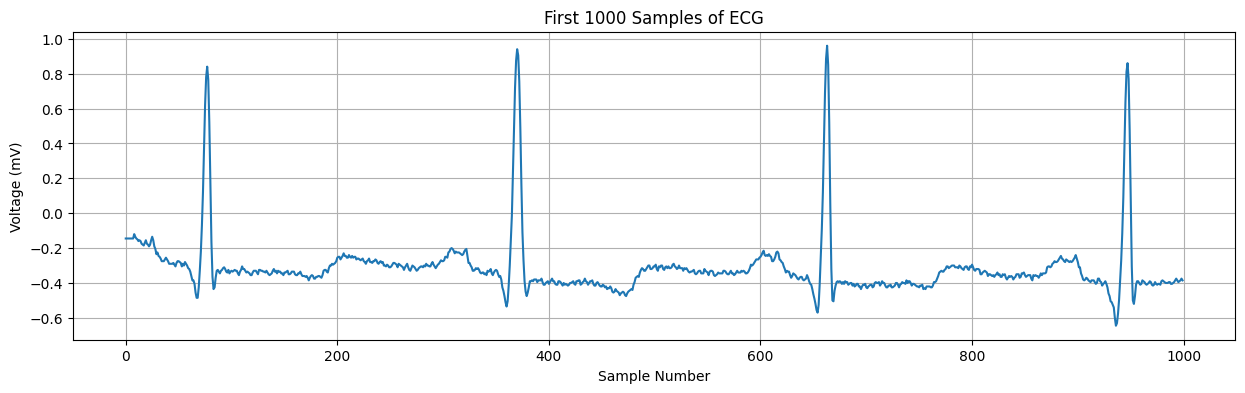

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

plt.plot(ecg[:1000])

plt.title("First 1000 Samples of ECG")

plt.xlabel("Sample Number")

plt.ylabel("Voltage (mV)")

plt.grid(True)

plt.show()

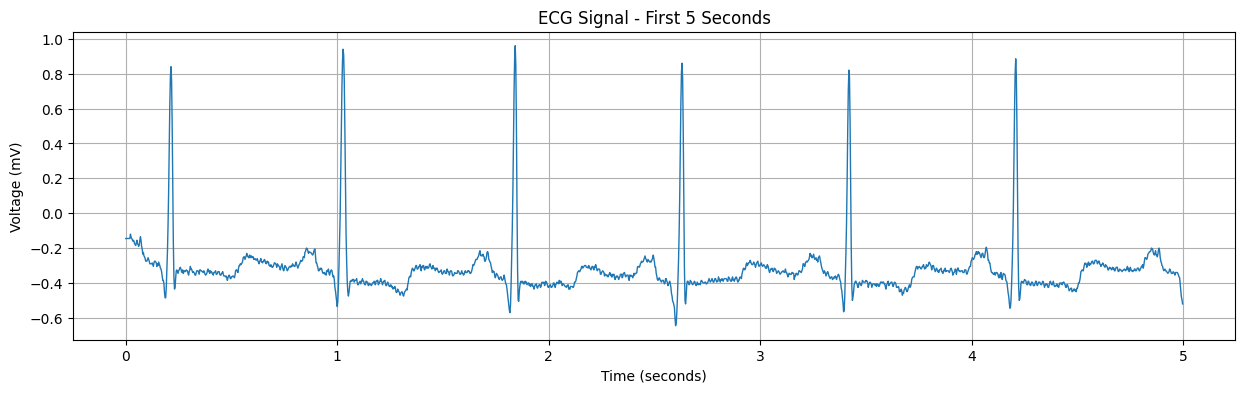

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Extract MLII lead
ecg = record.p_signal[:, 0]

# Create time axis
time = np.arange(len(ecg)) / record.fs

# Plot first 5 seconds
duration = 5  # seconds
samples = int(duration * record.fs)

plt.figure(figsize=(15,4))
plt.plot(time[:samples], ecg[:samples], linewidth=1)

plt.title(f"ECG Signal - First {duration} Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

In [16]:
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')
print(type(annotation))

<class 'wfdb.io.annotation.Annotation'>


In [17]:
print(annotation.sample[:20])

[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]


In [18]:
print(annotation.symbol[:20])

['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [19]:
print(len(annotation.sample))

2274


In [20]:
print(len(annotation.symbol))

2274


In [21]:
#time=sample/360
for sample, symbol in zip(annotation.sample[:20], annotation.symbol[:20]):
    print(sample, symbol)

18 +
77 N
370 N
662 N
946 N
1231 N
1515 N
1809 N
2044 A
2402 N
2706 N
2998 N
3282 N
3560 N
3862 N
4170 N
4466 N
4764 N
5060 N
5346 N


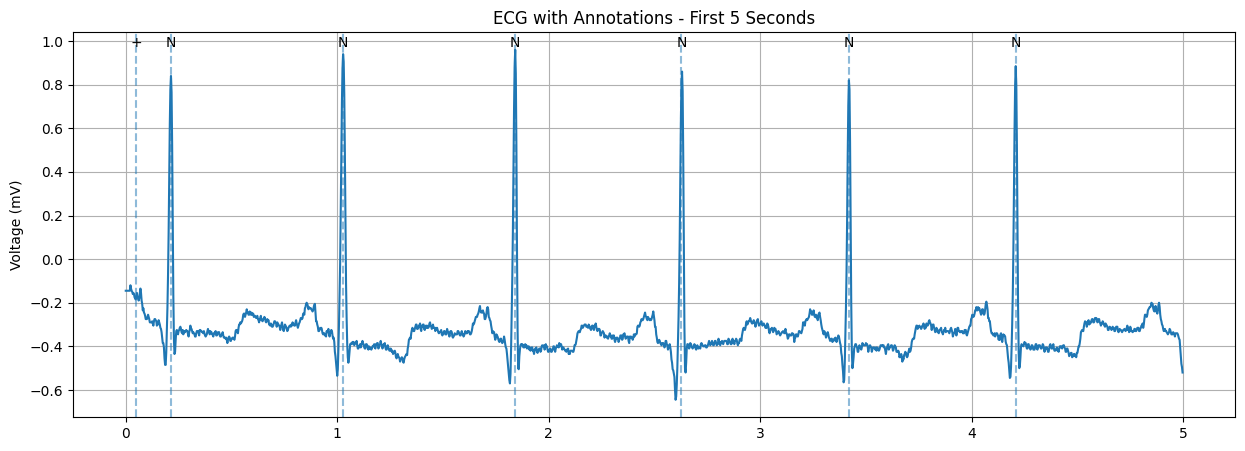

In [22]:
import matplotlib.pyplot as plt

# First 5 seconds
duration = 5
samples = int(duration * record.fs)

# Get annotations that occur within the first 5 seconds
mask = annotation.sample < samples

ann_samples = annotation.sample[mask]
ann_symbols = np.array(annotation.symbol)[mask]

# Convert annotation sample numbers to time
ann_times = ann_samples / record.fs

# Plot ECG
plt.figure(figsize=(15, 5))
plt.plot(time[:samples], ecg[:samples])

# Mark annotations
for t, symbol in zip(ann_times, ann_symbols):
    plt.axvline(t, linestyle='--', alpha=0.5)
    plt.text(t, max(ecg[:samples]), symbol,
             ha='center', va='bottom')

plt.title("ECG with Annotations - First 5 Seconds")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

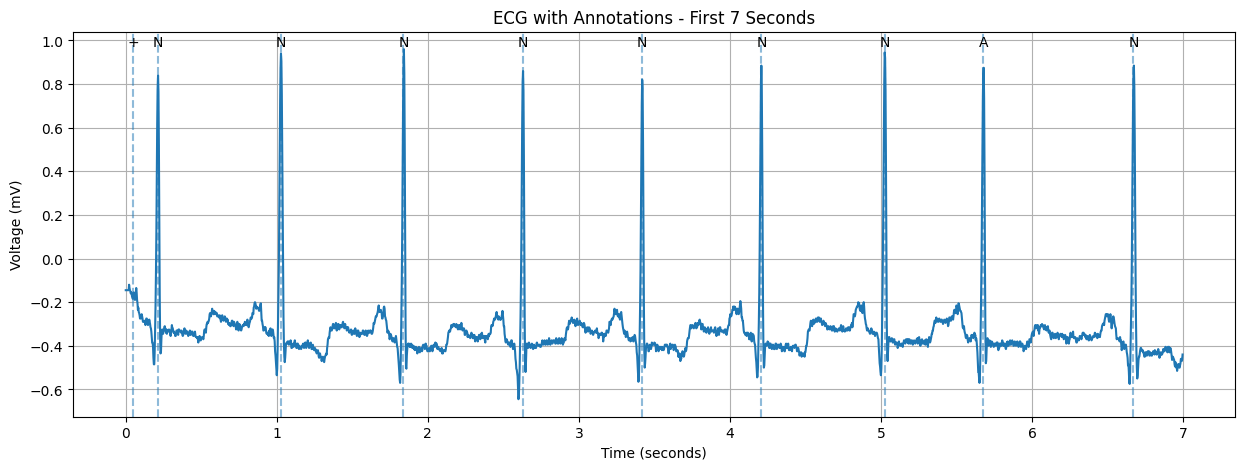

In [23]:
duration = 7
samples = int(duration * record.fs)

mask = annotation.sample < samples

ann_samples = annotation.sample[mask]
ann_symbols = np.array(annotation.symbol)[mask]

ann_times = ann_samples / record.fs

plt.figure(figsize=(15, 5))
plt.plot(time[:samples], ecg[:samples])

for t, symbol in zip(ann_times, ann_symbols):
    plt.axvline(t, linestyle='--', alpha=0.5)
    plt.text(t, max(ecg[:samples]), symbol,
             ha='center', va='bottom')

plt.title("ECG with Annotations - First 7 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

In [24]:
#Band pass Filter
from scipy.signal import butter, filtfilt

# Sampling frequency
fs = record.fs

# Filter settings
low_cutoff = 0.5
high_cutoff = 40

# Create a 4th-order Butterworth band-pass filter
b, a = butter(
    4,
    [low_cutoff, high_cutoff],
    btype='bandpass',
    fs=fs
)

# Apply the filter
ecg_filtered = filtfilt(b, a, ecg)

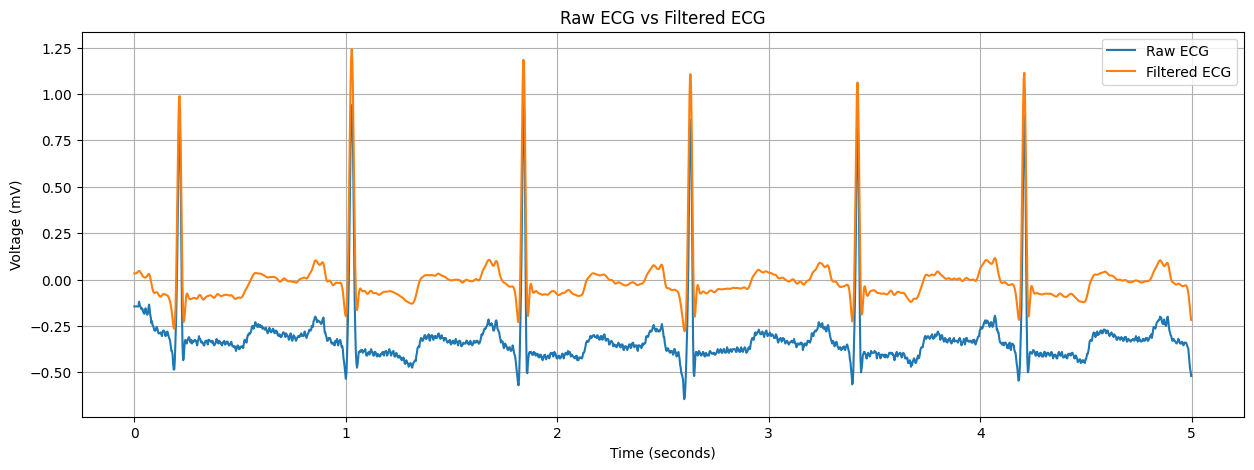

In [25]:
duration = 5
samples = int(duration * fs)

plt.figure(figsize=(15, 5))

plt.plot(time[:samples], ecg[:samples], label="Raw ECG")
plt.plot(time[:samples], ecg_filtered[:samples], label="Filtered ECG")

plt.title("Raw ECG vs Filtered ECG")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

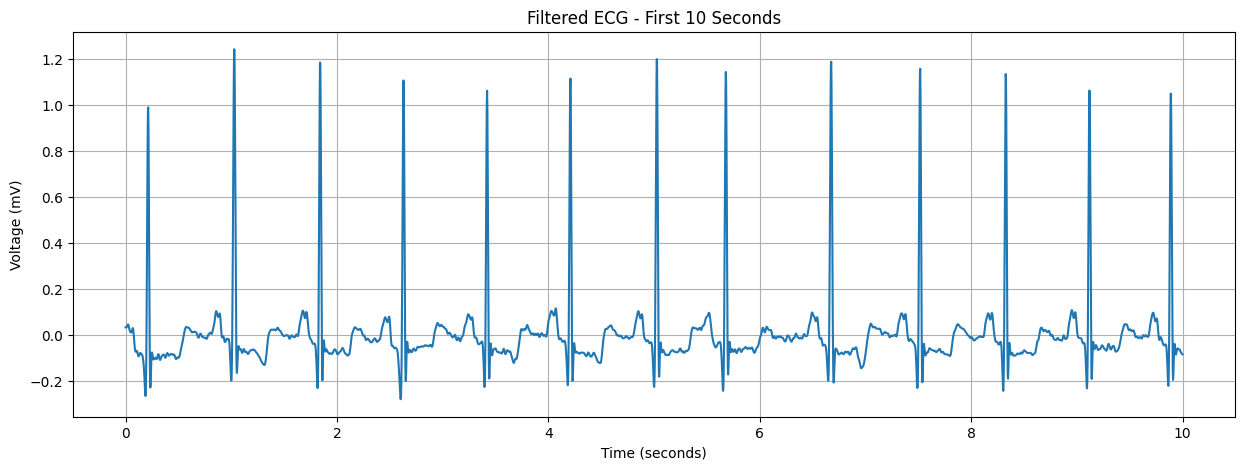

In [26]:
duration = 10
samples = int(duration * fs)

plt.figure(figsize=(15, 5))

plt.plot(time[:samples], ecg_filtered[:samples])

plt.title("Filtered ECG - First 10 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.grid(True)

plt.show()

In [27]:
from scipy.signal import find_peaks

r_peaks, properties = find_peaks(
    ecg_filtered,
    distance=int(0.25 * fs),
    prominence=0.5
)

print("Number of detected R-peaks:", len(r_peaks))
print("First 20 detected R-peaks:", r_peaks[:20])

Number of detected R-peaks: 2273
First 20 detected R-peaks: [  77  370  662  947 1231 1515 1809 2044 2403 2706 2997 3282 3559 3862
 4170 4466 4764 5060 5346 5634]


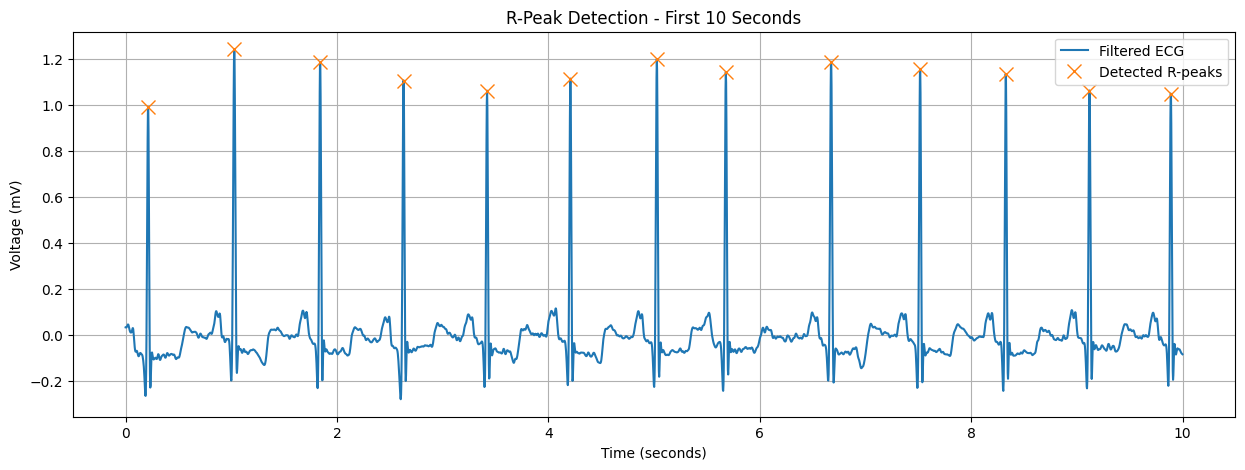

In [28]:
#R-peak Detection
duration = 10
samples = int(duration * fs)

# Only peaks within the first 10 seconds
peaks_10s = r_peaks[r_peaks < samples]

plt.figure(figsize=(15, 5))

plt.plot(
    time[:samples],
    ecg_filtered[:samples],
    label="Filtered ECG"
)

plt.plot(
    time[peaks_10s],
    ecg_filtered[peaks_10s],
    'x',
    markersize=10,
    label="Detected R-peaks"
)

plt.title("R-Peak Detection - First 10 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
r_peak_times = r_peaks / fs

print("First 20 R-peak times:")
print(r_peak_times[:20])

First 20 R-peak times:
[ 0.21388889  1.02777778  1.83888889  2.63055556  3.41944444  4.20833333
  5.025       5.67777778  6.675       7.51666667  8.325       9.11666667
  9.88611111 10.72777778 11.58333333 12.40555556 13.23333333 14.05555556
 14.85       15.65      ]


In [30]:
#Expert annotations vs our detected R-peaks.
# Expert annotation samples in first 10 seconds
annotation_samples_10s = annotation.sample[
    annotation.sample < int(10 * fs)
]

annotation_symbols_10s = np.array(annotation.symbol)[
    annotation.sample < int(10 * fs)
]

print("Expert annotations:")
for sample, symbol in zip(annotation_samples_10s, annotation_symbols_10s):
    print(f"Sample: {sample:4d} | Time: {sample/fs:.4f} s | Label: {symbol}")

Expert annotations:
Sample:   18 | Time: 0.0500 s | Label: +
Sample:   77 | Time: 0.2139 s | Label: N
Sample:  370 | Time: 1.0278 s | Label: N
Sample:  662 | Time: 1.8389 s | Label: N
Sample:  946 | Time: 2.6278 s | Label: N
Sample: 1231 | Time: 3.4194 s | Label: N
Sample: 1515 | Time: 4.2083 s | Label: N
Sample: 1809 | Time: 5.0250 s | Label: N
Sample: 2044 | Time: 5.6778 s | Label: A
Sample: 2402 | Time: 6.6722 s | Label: N
Sample: 2706 | Time: 7.5167 s | Label: N
Sample: 2998 | Time: 8.3278 s | Label: N
Sample: 3282 | Time: 9.1167 s | Label: N
Sample: 3560 | Time: 9.8889 s | Label: N


In [31]:
print("\nDetected R-peaks:")
for peak in r_peaks[r_peaks < int(10 * fs)]:
    print(f"Sample: {peak:4d} | Time: {peak/fs:.4f} s")


Detected R-peaks:
Sample:   77 | Time: 0.2139 s
Sample:  370 | Time: 1.0278 s
Sample:  662 | Time: 1.8389 s
Sample:  947 | Time: 2.6306 s
Sample: 1231 | Time: 3.4194 s
Sample: 1515 | Time: 4.2083 s
Sample: 1809 | Time: 5.0250 s
Sample: 2044 | Time: 5.6778 s
Sample: 2403 | Time: 6.6750 s
Sample: 2706 | Time: 7.5167 s
Sample: 2997 | Time: 8.3250 s
Sample: 3282 | Time: 9.1167 s
Sample: 3559 | Time: 9.8861 s


In [32]:
# Choose the first detected R-peak
peak = r_peaks[0]

# Number of samples before and after R-peak
before = int(0.2 * fs)
after = int(0.4 * fs)

# Extract the beat
beat = ecg_filtered[peak - before : peak + after]

print("R-peak sample:", peak)
print("Beat length:", len(beat))

R-peak sample: 77
Beat length: 216


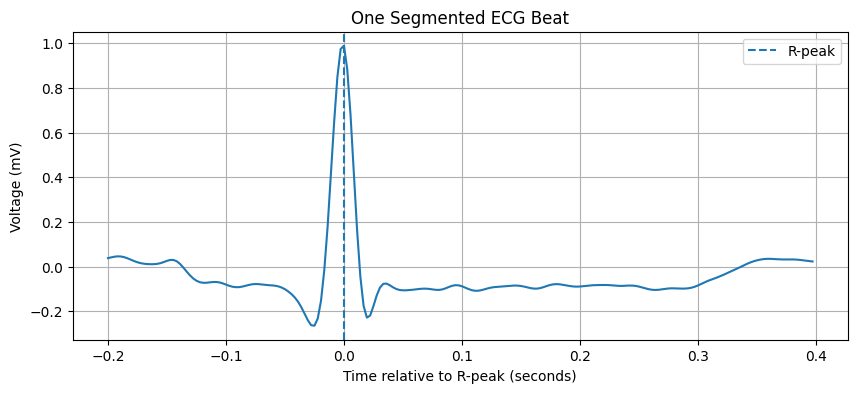

In [33]:
#Individual Heartbeat
beat_time = np.arange(len(beat)) / fs - 0.2

plt.figure(figsize=(10, 4))

plt.plot(beat_time, beat)

plt.axvline(0, linestyle='--', label='R-peak')

plt.title("One Segmented ECG Beat")
plt.xlabel("Time relative to R-peak (seconds)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

In [34]:
#All detected R-peaks
beats = []
beat_peak_positions = []

for peak in r_peaks:

    start = peak - before
    end = peak + after

    # Skip peaks too close to the beginning/end
    if start < 0 or end > len(ecg_filtered):
        continue

    beat = ecg_filtered[start:end]

    beats.append(beat)
    beat_peak_positions.append(peak)

beats = np.array(beats)
beat_peak_positions = np.array(beat_peak_positions)

print("Number of segmented beats:", len(beats))
print("Shape of beats array:", beats.shape)

Number of segmented beats: 2272
Shape of beats array: (2272, 216)


**Matching Detected peak and expert Annotation**


In [35]:
peak = r_peaks[0]

before = int(0.2 * fs)
after = int(0.4 * fs)

beat = ecg_filtered[peak - before : peak + after]

print("R-peak sample:", peak)
print("Beat length:", len(beat))

R-peak sample: 77
Beat length: 216


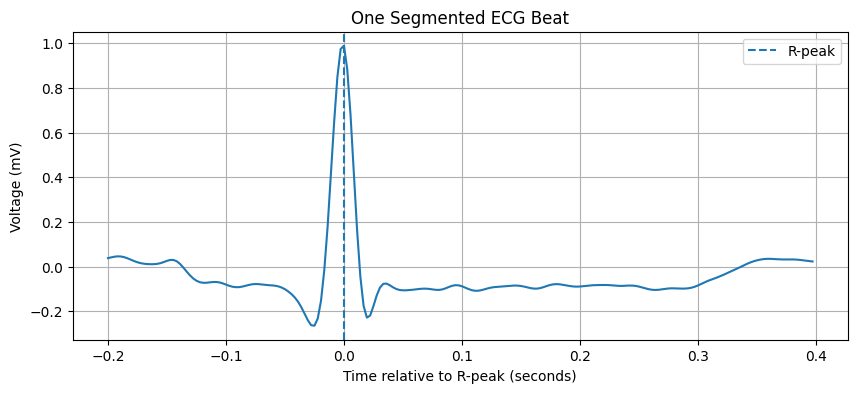

In [36]:
beat_time = np.arange(len(beat)) / fs - 0.2

plt.figure(figsize=(10, 4))

plt.plot(beat_time, beat)

plt.axvline(0, linestyle='--', label='R-peak')

plt.title("One Segmented ECG Beat")
plt.xlabel("Time relative to R-peak (seconds)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

**One beat -> All beats**

In [37]:
beats = []
beat_peak_positions = []

for peak in r_peaks:

    start = peak - before
    end = peak + after

    # Skip peaks too close to beginning/end
    if start < 0 or end > len(ecg_filtered):
        continue

    beat = ecg_filtered[start:end]

    beats.append(beat)
    beat_peak_positions.append(peak)

beats = np.array(beats)
beat_peak_positions = np.array(beat_peak_positions)

print("Number of segmented beats:", len(beats))
print("Shape of beats array:", beats.shape)

Number of segmented beats: 2272
Shape of beats array: (2272, 216)


**Filtered Annotations**

In [38]:
# Keep only the beat labels we currently want
valid_labels = ['N', 'A']

filtered_samples = []
filtered_symbols = []

for sample, symbol in zip(annotation.sample, annotation.symbol):
    if symbol in valid_labels:
        filtered_samples.append(sample)
        filtered_symbols.append(symbol)

filtered_samples = np.array(filtered_samples)
filtered_symbols = np.array(filtered_symbols)

print("Number of valid beat annotations:", len(filtered_samples))
print("First 20 samples:", filtered_samples[:20])
print("First 20 labels:", filtered_symbols[:20])

Number of valid beat annotations: 2272
First 20 samples: [  77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560 3862
 4170 4466 4764 5060 5346 5633]
First 20 labels: ['N' 'N' 'N' 'N' 'N' 'N' 'N' 'A' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N'
 'N' 'N']


In [39]:
from collections import Counter

beat_labels = [
    symbol for symbol in annotation.symbol
    if symbol in ['N', 'A']
]

print(Counter(beat_labels))

Counter({'N': 2239, 'A': 33})


In [40]:
print(np.unique(filtered_symbols))

['A' 'N']


In [41]:
from collections import Counter

print(Counter(filtered_symbols))

Counter({np.str_('N'): 2239, np.str_('A'): 33})


**Match detected beats to expert labels**
**(Beat Labelling)**

In [42]:
tolerance = int(0.05 * fs)

matched_labels = []
matched_peaks = []

for peak in beat_peak_positions:

    # Find closest expert annotation
    distances = np.abs(filtered_samples - peak)
    closest_index = np.argmin(distances)

    # Check whether it is close enough
    if distances[closest_index] <= tolerance:
        matched_peaks.append(peak)
        matched_labels.append(filtered_symbols[closest_index])

matched_labels = np.array(matched_labels)
matched_peaks = np.array(matched_peaks)

print("Matched beats:", len(matched_labels))
print("Matched label counts:", Counter(matched_labels))

Matched beats: 2271
Matched label counts: Counter({np.str_('N'): 2238, np.str_('A'): 33})


In [43]:
print("A beats:")

for peak, label in zip(matched_peaks, matched_labels):
    if label == 'A':
        print(
            f"Peak sample: {peak}, "
            f"Time: {peak/fs:.4f} s"
        )

A beats:
Peak sample: 2044, Time: 5.6778 s
Peak sample: 66792, Time: 185.5333 s
Peak sample: 74986, Time: 208.2944 s
Peak sample: 99579, Time: 276.6083 s
Peak sample: 128085, Time: 355.7917 s
Peak sample: 170719, Time: 474.2194 s
Peak sample: 279576, Time: 776.6000 s
Peak sample: 305709, Time: 849.1917 s
Peak sample: 307745, Time: 854.8472 s
Peak sample: 312826, Time: 868.9611 s
Peak sample: 317785, Time: 882.7361 s
Peak sample: 319223, Time: 886.7306 s
Peak sample: 346804, Time: 963.3444 s
Peak sample: 351481, Time: 976.3361 s
Peak sample: 377081, Time: 1047.4472 s
Peak sample: 397336, Time: 1103.7111 s
Peak sample: 421994, Time: 1172.2056 s
Peak sample: 422818, Time: 1174.4944 s
Peak sample: 433841, Time: 1205.1139 s
Peak sample: 436149, Time: 1211.5250 s
Peak sample: 442623, Time: 1229.5083 s
Peak sample: 444705, Time: 1235.2917 s
Peak sample: 454651, Time: 1262.9194 s
Peak sample: 458168, Time: 1272.6889 s
Peak sample: 496713, Time: 1379.7583 s
Peak sample: 520982, Time: 1447.1722 

In [44]:
unmatched_peaks = []

for peak in beat_peak_positions:
    distances = np.abs(filtered_samples - peak)
    closest_index = np.argmin(distances)

    if distances[closest_index] > tolerance:
        unmatched_peaks.append(
            (peak, distances[closest_index], filtered_samples[closest_index])
        )

print("Number of unmatched peaks:", len(unmatched_peaks))

for peak, distance, closest_annotation in unmatched_peaks:
    print(
        f"Detected peak: {peak} | "
        f"Time: {peak/fs:.4f} s | "
        f"Distance: {distance} samples | "
        f"Closest expert annotation: {closest_annotation}"
    )

Number of unmatched peaks: 1
Detected peak: 546888 | Time: 1519.1333 s | Distance: 289 samples | Closest expert annotation: 546599


In [45]:
print("Matched A beats:")

for peak, label in zip(matched_peaks, matched_labels):
    if label == 'A':
        print(f"Sample: {peak} | Time: {peak/fs:.4f} s")

Matched A beats:
Sample: 2044 | Time: 5.6778 s
Sample: 66792 | Time: 185.5333 s
Sample: 74986 | Time: 208.2944 s
Sample: 99579 | Time: 276.6083 s
Sample: 128085 | Time: 355.7917 s
Sample: 170719 | Time: 474.2194 s
Sample: 279576 | Time: 776.6000 s
Sample: 305709 | Time: 849.1917 s
Sample: 307745 | Time: 854.8472 s
Sample: 312826 | Time: 868.9611 s
Sample: 317785 | Time: 882.7361 s
Sample: 319223 | Time: 886.7306 s
Sample: 346804 | Time: 963.3444 s
Sample: 351481 | Time: 976.3361 s
Sample: 377081 | Time: 1047.4472 s
Sample: 397336 | Time: 1103.7111 s
Sample: 421994 | Time: 1172.2056 s
Sample: 422818 | Time: 1174.4944 s
Sample: 433841 | Time: 1205.1139 s
Sample: 436149 | Time: 1211.5250 s
Sample: 442623 | Time: 1229.5083 s
Sample: 444705 | Time: 1235.2917 s
Sample: 454651 | Time: 1262.9194 s
Sample: 458168 | Time: 1272.6889 s
Sample: 496713 | Time: 1379.7583 s
Sample: 520982 | Time: 1447.1722 s
Sample: 562812 | Time: 1563.3667 s
Sample: 566259 | Time: 1572.9417 s
Sample: 567380 | Time: 1

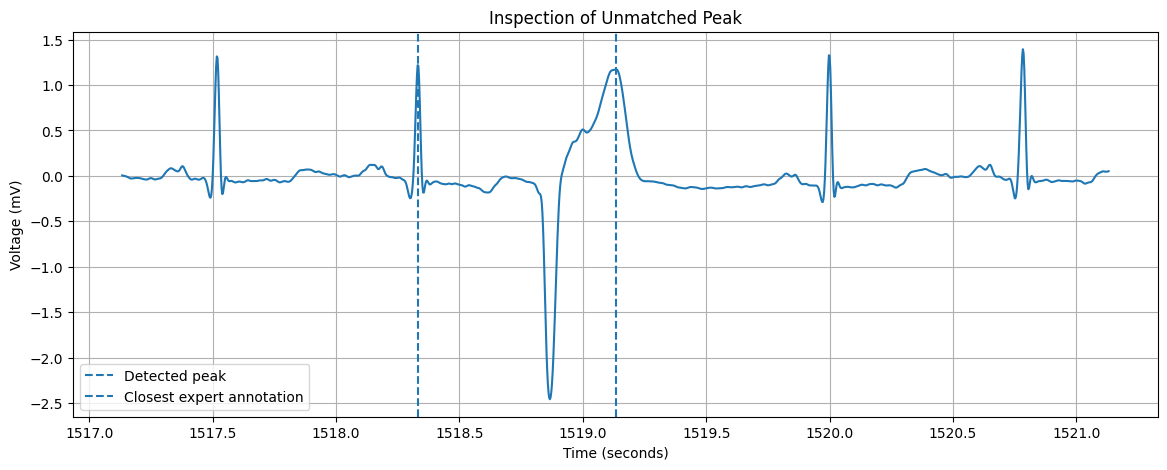

In [46]:
# Plot around the unmatched peak
peak = 546888

window = int(2 * fs)  # 2 seconds on each side

start = peak - window
end = peak + window

plt.figure(figsize=(14, 5))

plt.plot(
    time[start:end],
    ecg_filtered[start:end]
)

# Mark the detected peak
plt.axvline(
    time[peak],
    linestyle='--',
    label='Detected peak'
)

# Mark the closest expert annotation
closest_annotation = 546599

plt.axvline(
    time[closest_annotation],
    linestyle='--',
    label='Closest expert annotation'
)

plt.title("Inspection of Unmatched Peak")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

In [47]:
target = 546888

# Look at ALL expert annotations within ±2 seconds
window = int(2 * fs)

nearby = np.where(
    np.abs(annotation.sample - target) <= window
)[0]

print("All expert annotations near the unmatched peak:\n")

for i in nearby:
    sample = annotation.sample[i]
    symbol = annotation.symbol[i]

    print(
        f"Sample: {sample:6d} | "
        f"Time: {sample/fs:.4f} s | "
        f"Label: {symbol}"
    )

All expert annotations near the unmatched peak:

Sample: 546306 | Time: 1517.5167 s | Label: N
Sample: 546599 | Time: 1518.3306 s | Label: N
Sample: 546792 | Time: 1518.8667 s | Label: V
Sample: 547199 | Time: 1519.9972 s | Label: N
Sample: 547482 | Time: 1520.7833 s | Label: N


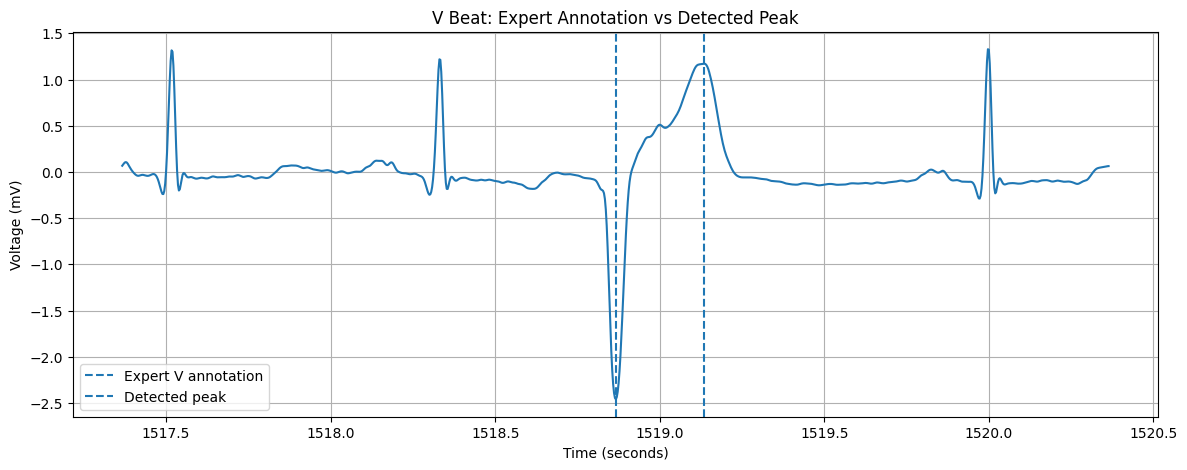

In [48]:
v_sample = 546792

window = int(1.5 * fs)

start = v_sample - window
end = v_sample + window

plt.figure(figsize=(14, 5))

plt.plot(
    time[start:end],
    ecg_filtered[start:end]
)

# Expert V annotation
plt.axvline(
    time[v_sample],
    linestyle='--',
    label='Expert V annotation'
)

# Our detected peak
plt.axvline(
    time[546888],
    linestyle='--',
    label='Detected peak'
)

plt.title("V Beat: Expert Annotation vs Detected Peak")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

In [49]:
from collections import Counter

selected_labels = [
    symbol for symbol in annotation.symbol
    if symbol in ['N', 'A', 'V']
]

print(Counter(selected_labels))

Counter({'N': 2239, 'A': 33, 'V': 1})


In [50]:
# Select the beat classes we want
selected_classes = ['N', 'A', 'V']

selected_samples = []
selected_labels = []

for sample, symbol in zip(annotation.sample, annotation.symbol):
    if symbol in selected_classes:
        selected_samples.append(sample)
        selected_labels.append(symbol)

selected_samples = np.array(selected_samples)
selected_labels = np.array(selected_labels)

print("Total selected beats:", len(selected_samples))
print("Class counts:", Counter(selected_labels))

Total selected beats: 2273
Class counts: Counter({np.str_('N'): 2239, np.str_('A'): 33, np.str_('V'): 1})


In [51]:
before = int(0.2 * fs)
after = int(0.4 * fs)

expert_beats = []
expert_labels = []

for sample, label in zip(selected_samples, selected_labels):

    start = sample - before
    end = sample + after

    # Skip annotations too close to the beginning/end
    if start < 0 or end > len(ecg_filtered):
        continue

    beat = ecg_filtered[start:end]

    # Make sure every beat has exactly 216 samples
    if len(beat) == before + after:
        expert_beats.append(beat)
        expert_labels.append(label)

expert_beats = np.array(expert_beats)
expert_labels = np.array(expert_labels)

print("Dataset shape:", expert_beats.shape)
print("Labels shape:", expert_labels.shape)
print("Class counts:", Counter(expert_labels))

Dataset shape: (2272, 216)
Labels shape: (2272,)
Class counts: Counter({np.str_('N'): 2238, np.str_('A'): 33, np.str_('V'): 1})


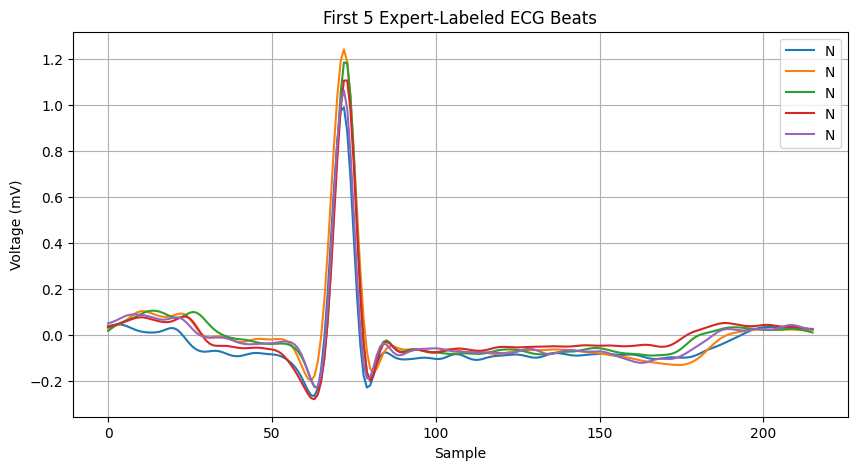

In [52]:
plt.figure(figsize=(10, 5))

for i in range(5):
    plt.plot(expert_beats[i], label=expert_labels[i])

plt.title("First 5 Expert-Labeled ECG Beats")
plt.xlabel("Sample")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

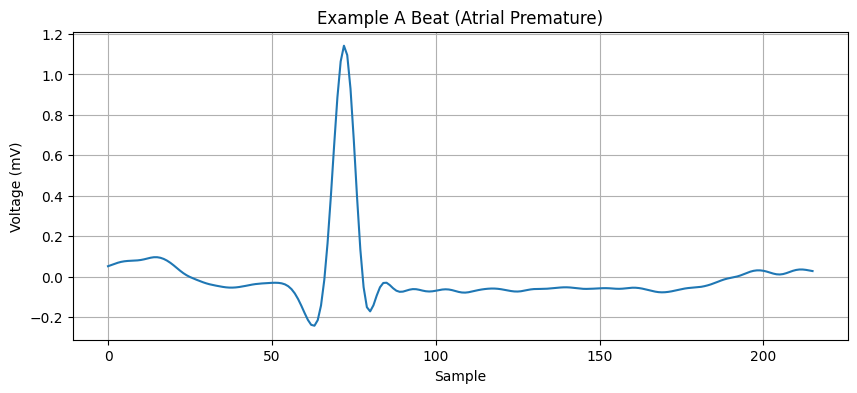

In [53]:
a_index = np.where(expert_labels == 'A')[0][0]

plt.figure(figsize=(10, 4))

plt.plot(expert_beats[a_index])

plt.title("Example A Beat (Atrial Premature)")
plt.xlabel("Sample")
plt.ylabel("Voltage (mV)")
plt.grid(True)

plt.show()

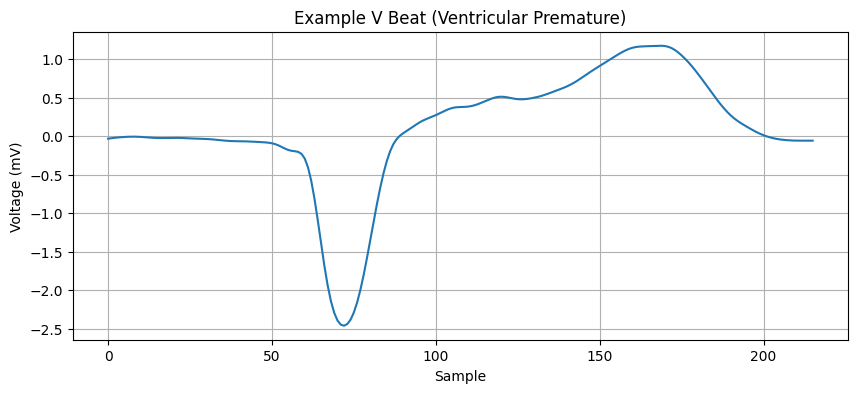

In [54]:
v_index = np.where(expert_labels == 'V')[0][0]

plt.figure(figsize=(10, 4))

plt.plot(expert_beats[v_index])

plt.title("Example V Beat (Ventricular Premature)")
plt.xlabel("Sample")
plt.ylabel("Voltage (mV)")
plt.grid(True)

plt.show()

**Visualizing Extracted Beats**

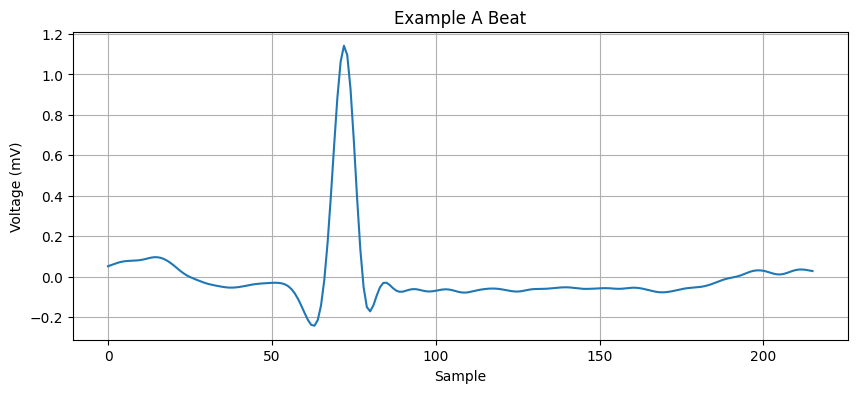

In [55]:
# Find the first A beat and the V beat
a_index = np.where(expert_labels == 'A')[0][0]
v_index = np.where(expert_labels == 'V')[0][0]

# Plot A beat
plt.figure(figsize=(10, 4))
plt.plot(expert_beats[a_index])

plt.title("Example A Beat")
plt.xlabel("Sample")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

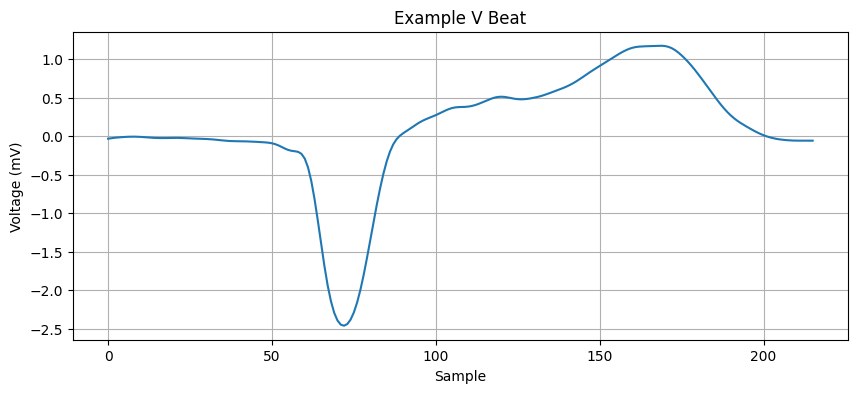

In [56]:
# Plot V beat
plt.figure(figsize=(10, 4))
plt.plot(expert_beats[v_index])

plt.title("Example V Beat")
plt.xlabel("Sample")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

**Load multiple MIT-BIH records**

In [57]:
import wfdb
from collections import Counter

records = [
    '100', '101', '102', '103', '104', '105', '106', '107',
    '108', '109', '111', '112', '113', '114', '115', '116',
    '117', '118', '119', '121', '122', '123', '124',
    '200', '201', '202', '203', '205', '207', '208', '209',
    '210', '212', '213', '214', '215', '217', '219', '220',
    '221', '222', '223', '228', '230', '231', '232', '233',
    '234'
]

results = []

for record_name in records:

    annotation = wfdb.rdann(
        record_name,
        'atr',
        pn_dir='mitdb'
    )

    counts = Counter(annotation.symbol)

    results.append({
        'Record': record_name,
        'N': counts.get('N', 0),
        'A': counts.get('A', 0),
        'V': counts.get('V', 0)
    })

for result in results:
    print(
        f"Record {result['Record']}: "
        f"N={result['N']}, "
        f"A={result['A']}, "
        f"V={result['V']}"
    )

Record 100: N=2239, A=33, V=1
Record 101: N=1860, A=3, V=0
Record 102: N=99, A=0, V=4
Record 103: N=2082, A=2, V=0
Record 104: N=163, A=0, V=2
Record 105: N=2526, A=0, V=41
Record 106: N=1507, A=0, V=520
Record 107: N=0, A=0, V=59
Record 108: N=1739, A=4, V=17
Record 109: N=0, A=0, V=38
Record 111: N=0, A=0, V=1
Record 112: N=2537, A=2, V=0
Record 113: N=1789, A=0, V=0
Record 114: N=1820, A=10, V=43
Record 115: N=1953, A=0, V=0
Record 116: N=2302, A=1, V=109
Record 117: N=1534, A=1, V=0
Record 118: N=0, A=96, V=16
Record 119: N=1543, A=0, V=444
Record 121: N=1861, A=1, V=1
Record 122: N=2476, A=0, V=0
Record 123: N=1515, A=0, V=3
Record 124: N=0, A=2, V=47
Record 200: N=1743, A=30, V=826
Record 201: N=1625, A=30, V=198
Record 202: N=2061, A=36, V=19
Record 203: N=2529, A=0, V=444
Record 205: N=2571, A=3, V=71
Record 207: N=0, A=107, V=105
Record 208: N=1586, A=0, V=992
Record 209: N=2621, A=383, V=1
Record 210: N=2423, A=0, V=194
Record 212: N=923, A=0, V=0
Record 213: N=2641, A=25, V=

In [58]:
import wfdb
import numpy as np
from scipy.signal import butter, filtfilt
from collections import Counter


def process_record(record_name):

    # -----------------------------
    # 1. Load ECG signal
    # -----------------------------
    record = wfdb.rdrecord(record_name, pn_dir='mitdb')

    # Use first ECG channel
    ecg = record.p_signal[:, 0]

    # Sampling frequency
    fs = record.fs

    # -----------------------------
    # 2. Filter ECG
    # -----------------------------
    lowcut = 0.5
    highcut = 40.0

    b, a = butter(
        4,
        [lowcut / (fs / 2),
         highcut / (fs / 2)],
        btype='band'
    )

    ecg_filtered = filtfilt(b, a, ecg)

    # -----------------------------
    # 3. Load expert annotations
    # -----------------------------
    annotation = wfdb.rdann(
        record_name,
        'atr',
        pn_dir='mitdb'
    )

    # -----------------------------
    # 4. Select N, A and V
    # -----------------------------
    selected_classes = ['N', 'A', 'V']

    samples = []
    labels = []

    for sample, symbol in zip(
        annotation.sample,
        annotation.symbol
    ):

        if symbol in selected_classes:
            samples.append(sample)
            labels.append(symbol)

    samples = np.array(samples)
    labels = np.array(labels)

    # -----------------------------
    # 5. Beat segmentation
    # -----------------------------
    before = int(0.2 * fs)
    after = int(0.4 * fs)

    beats = []
    beat_labels = []

    for sample, label in zip(samples, labels):

        start = sample - before
        end = sample + after

        # Ignore beats too close to boundaries
        if start < 0 or end > len(ecg_filtered):
            continue

        beat = ecg_filtered[start:end]

        # Make sure every beat has 216 samples
        if len(beat) == before + after:
            beats.append(beat)
            beat_labels.append(label)

    beats = np.array(beats)
    beat_labels = np.array(beat_labels)

    # -----------------------------
    # 6. Return results
    # -----------------------------
    return beats, beat_labels

In [59]:
beats_106, labels_106 = process_record('106')

print("Shape of beats:", beats_106.shape)
print("Shape of labels:", labels_106.shape)
print("Class counts:", Counter(labels_106))

Shape of beats: (2027, 216)
Shape of labels: (2027,)
Class counts: Counter({np.str_('N'): 1507, np.str_('V'): 520})


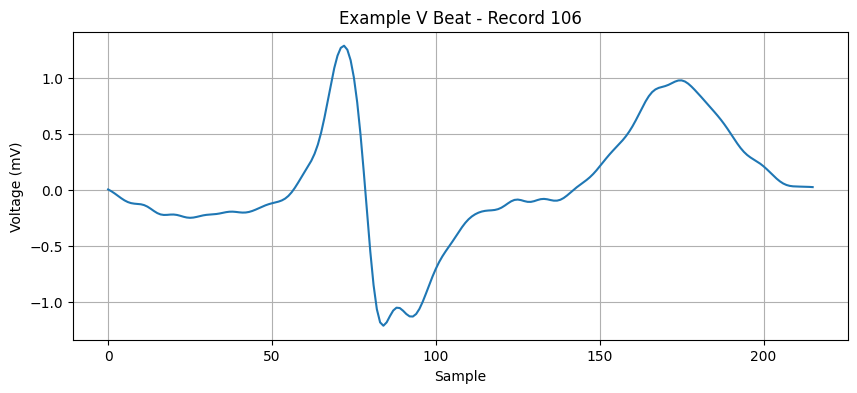

In [60]:
v_index = np.where(labels_106 == 'V')[0][0]

plt.figure(figsize=(10, 4))

plt.plot(beats_106[v_index])

plt.title("Example V Beat - Record 106")
plt.xlabel("Sample")
plt.ylabel("Voltage (mV)")
plt.grid(True)

plt.show()

In [61]:
train_records = [
    '100',
    '106',
    '114',
    '116',
    '119',
    '201',
    '205',
    '223',
    '228',
    '233'
]

val_records = [
    '202',
    '213'
]

test_records = [
    '200',
    '219'
]

print("Training records:", train_records)
print("Validation records:", val_records)
print("Test records:", test_records)

Training records: ['100', '106', '114', '116', '119', '201', '205', '223', '228', '233']
Validation records: ['202', '213']
Test records: ['200', '219']


In [62]:
train_beats_list = []
train_labels_list = []

for record_name in train_records:

    print("Processing record:", record_name)

    beats, labels = process_record(record_name)

    train_beats_list.append(beats)
    train_labels_list.append(labels)

    print("  Beats:", beats.shape[0])
    print("  Classes:", Counter(labels))


# Combine all training records
X_train = np.concatenate(train_beats_list, axis=0)
y_train = np.concatenate(train_labels_list, axis=0)

print("\nFinal training dataset:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Class distribution:", Counter(y_train))

Processing record: 100
  Beats: 2272
  Classes: Counter({np.str_('N'): 2238, np.str_('A'): 33, np.str_('V'): 1})
Processing record: 106
  Beats: 2027
  Classes: Counter({np.str_('N'): 1507, np.str_('V'): 520})
Processing record: 114
  Beats: 1873
  Classes: Counter({np.str_('N'): 1820, np.str_('V'): 43, np.str_('A'): 10})
Processing record: 116
  Beats: 2411
  Classes: Counter({np.str_('N'): 2301, np.str_('V'): 109, np.str_('A'): 1})
Processing record: 119
  Beats: 1987
  Classes: Counter({np.str_('N'): 1543, np.str_('V'): 444})
Processing record: 201
  Beats: 1853
  Classes: Counter({np.str_('N'): 1625, np.str_('V'): 198, np.str_('A'): 30})
Processing record: 205
  Beats: 2644
  Classes: Counter({np.str_('N'): 2570, np.str_('V'): 71, np.str_('A'): 3})
Processing record: 223
  Beats: 2574
  Classes: Counter({np.str_('N'): 2029, np.str_('V'): 473, np.str_('A'): 72})
Processing record: 228
  Beats: 2053
  Classes: Counter({np.str_('N'): 1688, np.str_('V'): 362, np.str_('A'): 3})
Processi

**Validation Dataset**

In [63]:
val_beats_list = []
val_labels_list = []

for record_name in val_records:

    print("Processing validation record:", record_name)

    beats, labels = process_record(record_name)

    val_beats_list.append(beats)
    val_labels_list.append(labels)

    print("  Beats:", beats.shape[0])
    print("  Classes:", Counter(labels))


X_val = np.concatenate(val_beats_list, axis=0)
y_val = np.concatenate(val_labels_list, axis=0)

print("\nFinal validation dataset:")
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("Class distribution:", Counter(y_val))

Processing validation record: 202
  Beats: 2115
  Classes: Counter({np.str_('N'): 2060, np.str_('A'): 36, np.str_('V'): 19})
Processing validation record: 213
  Beats: 2885
  Classes: Counter({np.str_('N'): 2640, np.str_('V'): 220, np.str_('A'): 25})

Final validation dataset:
X_val shape: (5000, 216)
y_val shape: (5000,)
Class distribution: Counter({np.str_('N'): 4700, np.str_('V'): 239, np.str_('A'): 61})


**Test Dataset**

In [64]:
test_beats_list = []
test_labels_list = []

for record_name in test_records:

    print("Processing test record:", record_name)

    beats, labels = process_record(record_name)

    test_beats_list.append(beats)
    test_labels_list.append(labels)

    print("  Beats:", beats.shape[0])
    print("  Classes:", Counter(labels))


X_test = np.concatenate(test_beats_list, axis=0)
y_test = np.concatenate(test_labels_list, axis=0)

print("\nFinal test dataset:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Class distribution:", Counter(y_test))

Processing test record: 200
  Beats: 2598
  Classes: Counter({np.str_('N'): 1742, np.str_('V'): 826, np.str_('A'): 30})
Processing test record: 219
  Beats: 2153
  Classes: Counter({np.str_('N'): 2082, np.str_('V'): 64, np.str_('A'): 7})

Final test dataset:
X_test shape: (4751, 216)
y_test shape: (4751,)
Class distribution: Counter({np.str_('N'): 3824, np.str_('V'): 890, np.str_('A'): 37})


In [65]:
label_map = {
    'N': 0,
    'A': 1,
    'V': 2
}

y_train_encoded = np.array([
    label_map[label] for label in y_train
])

y_val_encoded = np.array([
    label_map[label] for label in y_val
])

y_test_encoded = np.array([
    label_map[label] for label in y_test
])

print("Training labels:", Counter(y_train_encoded))
print("Validation labels:", Counter(y_val_encoded))
print("Test labels:", Counter(y_test_encoded))

Training labels: Counter({np.int64(0): 19550, np.int64(2): 3051, np.int64(1): 159})
Validation labels: Counter({np.int64(0): 4700, np.int64(2): 239, np.int64(1): 61})
Test labels: Counter({np.int64(0): 3824, np.int64(2): 890, np.int64(1): 37})


**Normalization**

In [66]:
def normalize_beats(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)

    # Avoid division by zero
    std[std == 0] = 1

    return (X - mean) / std


X_train_norm = normalize_beats(X_train)
X_val_norm = normalize_beats(X_val)
X_test_norm = normalize_beats(X_test)

print("Training:", X_train_norm.shape)
print("Validation:", X_val_norm.shape)
print("Test:", X_test_norm.shape)

Training: (22760, 216)
Validation: (5000, 216)
Test: (4751, 216)


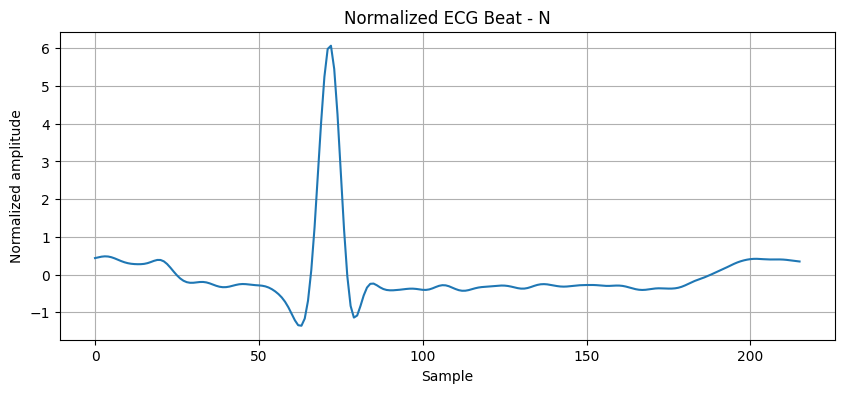

In [67]:
plt.figure(figsize=(10, 4))

plt.plot(X_train_norm[0])

plt.title("Normalized ECG Beat - N")
plt.xlabel("Sample")
plt.ylabel("Normalized amplitude")
plt.grid(True)

plt.show()

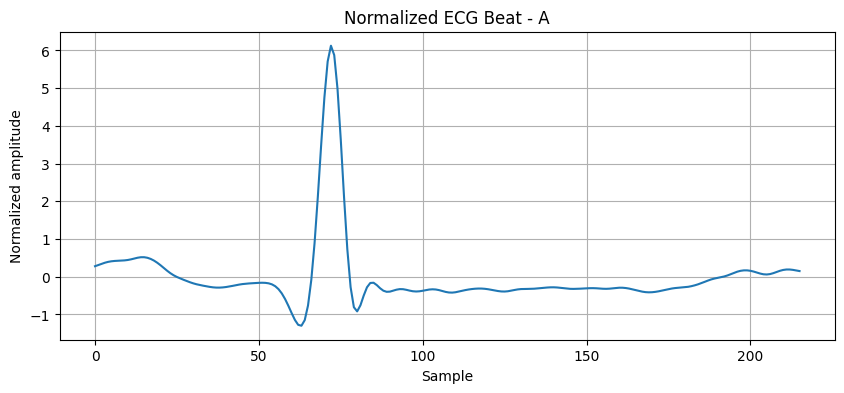

In [68]:
a_index = np.where(y_train_encoded == 1)[0][0]

plt.figure(figsize=(10, 4))

plt.plot(X_train_norm[a_index])

plt.title("Normalized ECG Beat - A")
plt.xlabel("Sample")
plt.ylabel("Normalized amplitude")
plt.grid(True)

plt.show()

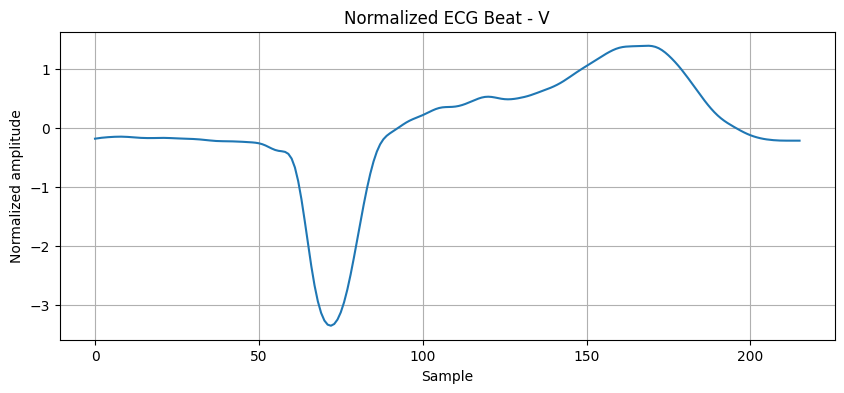

In [69]:
v_index = np.where(y_train_encoded == 2)[0][0]

plt.figure(figsize=(10, 4))

plt.plot(X_train_norm[v_index])

plt.title("Normalized ECG Beat - V")
plt.xlabel("Sample")
plt.ylabel("Normalized amplitude")
plt.grid(True)

plt.show()

**Calculating Class Weights**

In [70]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_encoded)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_encoded
)

class_weights = dict(
    zip(classes, class_weights_array)
)

print("Class weights:")

for class_id, weight in class_weights.items():
    print(
        f"Class {class_id}: {weight:.3f}"
    )

Class weights:
Class 0: 0.388
Class 1: 47.715
Class 2: 2.487


**Random Forest**

In [71]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created.")

Random Forest model created.


In [72]:
rf_model.fit(
    X_train_norm,
    y_train_encoded
)

print("Training completed!")

Training completed!


**Testing on Validation data**

In [73]:
y_val_pred = rf_model.predict(X_val_norm)

print("Validation predictions completed!")
print("Number of predictions:", len(y_val_pred))

Validation predictions completed!
Number of predictions: 5000


**Validation Accuracy**

In [74]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred
)

print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.9846


In [75]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_val_encoded,
    y_val_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4694    3    3]
 [  61    0    0]
 [  10    0  229]]


In [76]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val_encoded,
        y_val_pred,
        target_names=['N', 'A', 'V'],
        zero_division=0
    )
)

              precision    recall  f1-score   support

           N       0.99      1.00      0.99      4700
           A       0.00      0.00      0.00        61
           V       0.99      0.96      0.97       239

    accuracy                           0.98      5000
   macro avg       0.66      0.65      0.65      5000
weighted avg       0.97      0.98      0.98      5000



**1D CNN**

In [77]:
X_train_cnn = X_train_norm[..., np.newaxis]
X_val_cnn = X_val_norm[..., np.newaxis]
X_test_cnn = X_test_norm[..., np.newaxis]

print("Training CNN input:", X_train_cnn.shape)
print("Validation CNN input:", X_val_cnn.shape)
print("Test CNN input:", X_test_cnn.shape)

Training CNN input: (22760, 216, 1)
Validation CNN input: (5000, 216, 1)
Test CNN input: (4751, 216, 1)


In [78]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

cnn_model = Sequential([

    # First convolution block
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(216, 1)
    ),

    BatchNormalization(),

    MaxPooling1D(
        pool_size=2
    ),

    # Second convolution block
    Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling1D(
        pool_size=2
    ),

    # Convert feature maps to a vector
    Flatten(),

    # Fully connected layer
    Dense(
        64,
        activation='relu'
    ),

    # Reduce overfitting
    Dropout(0.5),

    # Output: N, A, V
    Dense(
        3,
        activation='softmax'
    )
])

cnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 212, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 212, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 106, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 102, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 102, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 51, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3264)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       208,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,035 (859.51 KB)

 Trainable params: 219,843 (858.76 KB)

 Non-trainable params: 192 (768.00 B)

In [79]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN compiled successfully!")

CNN compiled successfully!


In [80]:
history = cnn_model.fit(
    X_train_cnn,
    y_train_encoded,
    validation_data=(X_val_cnn, y_val_encoded),
    epochs=15,
    batch_size=64,
    class_weight=class_weights
)

Epoch 1/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.7001 - loss: 0.7605 - val_accuracy: 0.0728 - val_loss: 0.8857
Epoch 2/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.7669 - loss: 0.4408 - val_accuracy: 0.6320 - val_loss: 0.6315
Epoch 3/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.8443 - loss: 0.3819 - val_accuracy: 0.7336 - val_loss: 0.5194
Epoch 4/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.8370 - loss: 0.3368 - val_accuracy: 0.7602 - val_loss: 0.5068
Epoch 5/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.8467 - loss: 0.3560 - val_accuracy: 0.7556 - val_loss: 0.5292
Epoch 6/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.8633 - loss: 0.3117 - val_accuracy: 0.7806 - val_loss: 0.5013
Epoch 7/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.8535 - loss: 0.3390 - val_accuracy: 0.7066 - val_loss: 0.7246
Epoch 8/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.8476 - loss: 0.3132 - 

In [81]:
y_val_cnn_prob = cnn_model.predict(X_val_cnn)

y_val_cnn_pred = np.argmax(
    y_val_cnn_prob,
    axis=1
)

print("CNN validation predictions completed.")
print("Number of predictions:", len(y_val_cnn_pred))

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
CNN validation predictions completed.
Number of predictions: 5000


In [82]:
from sklearn.metrics import confusion_matrix

cm_cnn = confusion_matrix(
    y_val_encoded,
    y_val_cnn_pred
)

print("CNN Confusion Matrix:")
print(cm_cnn)

CNN Confusion Matrix:
[[2793 1879   28]
 [   8   52    1]
 [   1    2  236]]


In [83]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val_encoded,
        y_val_cnn_pred,
        target_names=['N', 'A', 'V'],
        zero_division=0
    )
)

              precision    recall  f1-score   support

           N       1.00      0.59      0.74      4700
           A       0.03      0.85      0.05        61
           V       0.89      0.99      0.94       239

    accuracy                           0.62      5000
   macro avg       0.64      0.81      0.58      5000
weighted avg       0.98      0.62      0.75      5000



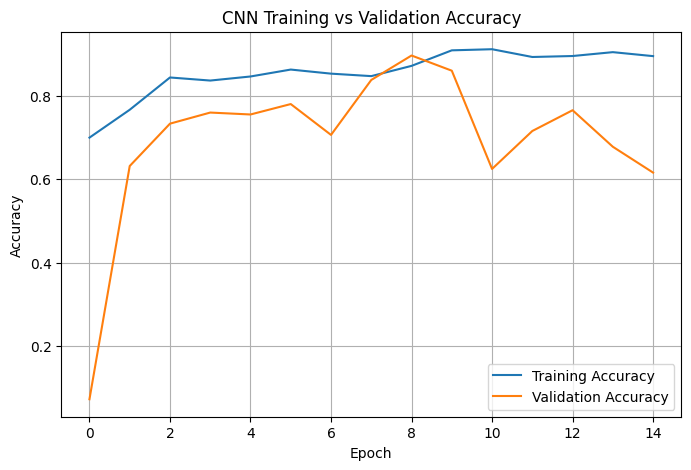

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

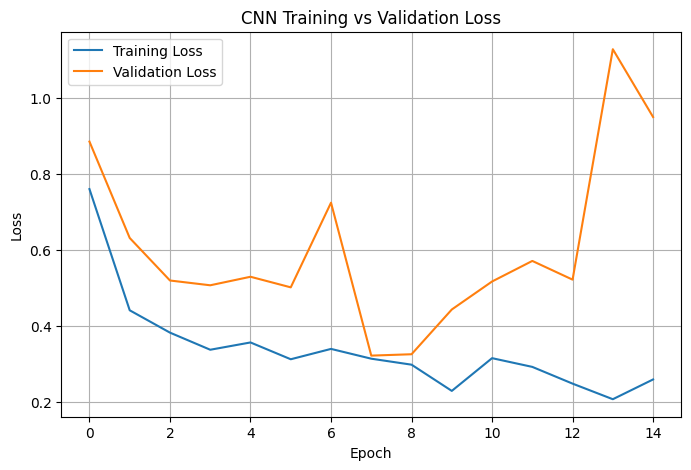

In [85]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

In [86]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

cnn_model = Sequential([

    Input(shape=(216, 1)),

    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu'
    ),

    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'
    ),

    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(64, activation='relu'),

    Dropout(0.5),

    Dense(3, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 212, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 212, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 106, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 102, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 102, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 51, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3264)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       208,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,035 (859.51 KB)

 Trainable params: 219,843 (858.76 KB)

 Non-trainable params: 192 (768.00 B)

In [87]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    'best_cnn_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [88]:
history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train_encoded,
    validation_data=(X_val_cnn, y_val_encoded),
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.7149 - loss: 0.9776 - val_accuracy: 0.0866 - val_loss: 1.1325 - learning_rate: 0.0010
Epoch 2/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.7138 - loss: 0.5108 - val_accuracy: 0.7120 - val_loss: 0.6208 - learning_rate: 0.0010
Epoch 3/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.7865 - loss: 0.4741 - val_accuracy: 0.7478 - val_loss: 0.6229 - learning_rate: 0.0010
Epoch 4/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.8102 - loss: 0.3891 - val_accuracy: 0.8116 - val_loss: 0.5292 - learning_rate: 0.0010
Epoch 5/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.8514 - loss: 0.3375 - val_accuracy: 0.7846 - val_loss: 0.5374 - learning_rate: 0.0010
Epoch 6/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.8842 - loss: 0.2931 - val_accuracy: 0.8934 - val_loss: 0.2780 - learning_rate: 0.0010
Epoch 7/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.8705 - l

In [89]:
print("Training completed.")

print("Best validation accuracy:",
      max(history_cnn.history['val_accuracy']))

print("Best validation loss:",
      min(history_cnn.history['val_loss']))

print("Best epoch:",
      np.argmax(history_cnn.history['val_accuracy']) + 1)

Training completed.
Best validation accuracy: 0.8934000134468079
Best validation loss: 0.27798229455947876
Best epoch: 6


**Improved CNN**

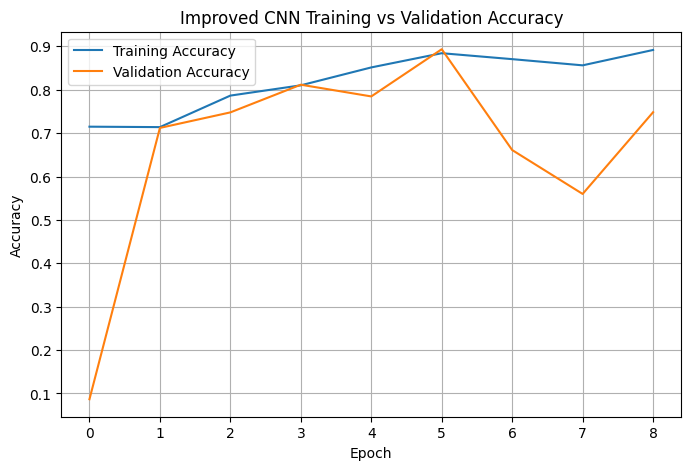

In [90]:
plt.figure(figsize=(8, 5))

plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Improved CNN Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

**Loss**

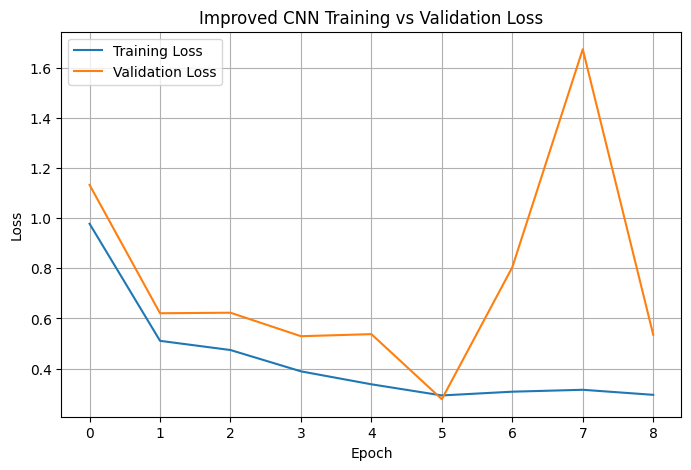

In [91]:
plt.figure(figsize=(8, 5))

plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Improved CNN Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [92]:
y_val_pred_prob = cnn_model.predict(X_val_cnn)

y_val_pred = np.argmax(y_val_pred_prob, axis=1)

print("Improved CNN validation predictions completed.")
print("Number of predictions:", len(y_val_pred))

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Improved CNN validation predictions completed.
Number of predictions: 5000


In [93]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_val_encoded, y_val_pred)

print("Improved CNN Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_val_encoded,
    y_val_pred,
    target_names=['N', 'A', 'V'],
    zero_division=0
))

Improved CNN Confusion Matrix:
[[4219  480    1]
 [  48   12    1]
 [   2    1  236]]

Classification Report:
              precision    recall  f1-score   support

           N       0.99      0.90      0.94      4700
           A       0.02      0.20      0.04        61
           V       0.99      0.99      0.99       239

    accuracy                           0.89      5000
   macro avg       0.67      0.69      0.66      5000
weighted avg       0.98      0.89      0.93      5000



In [94]:
# CNN predictions on the test dataset

y_test_pred_prob = cnn_model.predict(X_test_cnn)

y_test_pred = np.argmax(y_test_pred_prob, axis=1)

print("CNN test predictions completed.")
print("Number of predictions:", len(y_test_pred))

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
CNN test predictions completed.
Number of predictions: 4751


In [95]:
from sklearn.metrics import confusion_matrix, classification_report

cm_test_cnn = confusion_matrix(
    y_test_encoded,
    y_test_pred
)

print("CNN Test Confusion Matrix:")
print(cm_test_cnn)

print("\nCNN Test Classification Report:")

print(classification_report(
    y_test_encoded,
    y_test_pred,
    target_names=['N', 'A', 'V'],
    zero_division=0
))

CNN Test Confusion Matrix:
[[2222 1586   16]
 [  20   17    0]
 [  13   20  857]]

CNN Test Classification Report:
              precision    recall  f1-score   support

           N       0.99      0.58      0.73      3824
           A       0.01      0.46      0.02        37
           V       0.98      0.96      0.97       890

    accuracy                           0.65      4751
   macro avg       0.66      0.67      0.57      4751
weighted avg       0.98      0.65      0.77      4751



In [96]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

label_encoder.fit(['N', 'A', 'V'])

y_test_encoded = label_encoder.transform(y_test)

print("Test labels encoded:")
print(Counter(y_test_encoded))

Test labels encoded:
Counter({np.int64(1): 3824, np.int64(2): 890, np.int64(0): 37})


**Solving the A class imbalance**

In [97]:
from collections import Counter

print("Before oversampling:")
print(Counter(y_train_encoded))

Before oversampling:
Counter({np.int64(0): 19550, np.int64(2): 3051, np.int64(1): 159})


In [98]:
import numpy as np
from sklearn.utils import resample
from collections import Counter

# Separate the three classes
X_N = X_train[y_train_encoded == 0]
X_A = X_train[y_train_encoded == 1]
X_V = X_train[y_train_encoded == 2]

# Oversample A to 3,000 samples
X_A_oversampled = resample(
    X_A,
    replace=True,
    n_samples=3000,
    random_state=42
)

# Keep N and V unchanged
X_train_balanced = np.concatenate([
    X_N,
    X_A_oversampled,
    X_V
])

y_train_balanced = np.concatenate([
    np.zeros(len(X_N), dtype=int),
    np.ones(len(X_A_oversampled), dtype=int),
    np.full(len(X_V), 2, dtype=int)
])

# Shuffle the new training dataset
shuffle_indices = np.random.RandomState(42).permutation(
    len(X_train_balanced)
)

X_train_balanced = X_train_balanced[shuffle_indices]
y_train_balanced = y_train_balanced[shuffle_indices]

print("After oversampling:")
print("X_train_balanced shape:", X_train_balanced.shape)
print("y_train_balanced shape:", y_train_balanced.shape)
print("Class distribution:", Counter(y_train_balanced))

After oversampling:
X_train_balanced shape: (25601, 216)
y_train_balanced shape: (25601,)
Class distribution: Counter({np.int64(0): 19550, np.int64(2): 3051, np.int64(1): 3000})


In [99]:
X_train_balanced_cnn = X_train_balanced.reshape(
    X_train_balanced.shape[0],
    X_train_balanced.shape[1],
    1
)

print("Balanced CNN training input:", X_train_balanced_cnn.shape)
print("Balanced training labels:", y_train_balanced.shape)

Balanced CNN training input: (25601, 216, 1)
Balanced training labels: (25601,)


**Build CNN using the balanced training data**

In [100]:
#Model Architecture
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

balanced_cnn = Sequential([

    Input(shape=(216, 1)),

    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu'
    ),

    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'
    ),

    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(64, activation='relu'),

    Dropout(0.5),

    Dense(3, activation='softmax')
])

balanced_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

balanced_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 212, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 212, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 106, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 102, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 102, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 51, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3264)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       208,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,035 (859.51 KB)

 Trainable params: 219,843 (858.76 KB)

 Non-trainable params: 192 (768.00 B)

In [101]:
early_stopping_balanced = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr_balanced = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

checkpoint_balanced = ModelCheckpoint(
    'best_balanced_cnn.keras',
    monitor='val_loss',
    save_best_only=True
)

In [102]:
history_balanced = balanced_cnn.fit(
    X_train_balanced_cnn,
    y_train_balanced,
    validation_data=(X_val_cnn, y_val_encoded),
    epochs=20,
    batch_size=64,
    callbacks=[
        early_stopping_balanced,
        reduce_lr_balanced,
        checkpoint_balanced
    ]
)

Epoch 1/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.9258 - loss: 0.2101 - val_accuracy: 0.9562 - val_loss: 0.1909 - learning_rate: 0.0010
Epoch 2/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9586 - loss: 0.1132 - val_accuracy: 0.8968 - val_loss: 0.5978 - learning_rate: 0.0010
Epoch 3/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.9685 - loss: 0.0857 - val_accuracy: 0.8998 - val_loss: 0.4799 - learning_rate: 0.0010
Epoch 4/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.9819 - loss: 0.0505 - val_accuracy: 0.9384 - val_loss: 0.4046 - learning_rate: 5.0000e-04


In [103]:
print("Epochs actually completed:", len(history_balanced.history['loss']))

print("\nTraining accuracy:")
print(history_balanced.history['accuracy'])

print("\nValidation accuracy:")
print(history_balanced.history['val_accuracy'])

Epochs actually completed: 4

Training accuracy:
[0.9258232116699219, 0.9585953950881958, 0.9684777855873108, 0.981914758682251]

Validation accuracy:
[0.9562000036239624, 0.8967999815940857, 0.8998000025749207, 0.9383999705314636]


In [104]:
print("Early stopping patience:", early_stopping_balanced.patience)
print("Early stopping monitor:", early_stopping_balanced.monitor)
print("Early stopping mode:", early_stopping_balanced.mode)
print("Restore best weights:", early_stopping_balanced.restore_best_weights)

Early stopping patience: 3
Early stopping monitor: val_loss
Early stopping mode: auto
Restore best weights: True


In [105]:
print("Available models:")

for name in [
    "cnn_model",
    "balanced_cnn",
    "weighted_cnn"
]:
    if name in globals():
        print(name, "✓ available")
    else:
        print(name, "✗ not available")

Available models:
cnn_model ✓ available
balanced_cnn ✓ available
weighted_cnn ✗ not available


In [106]:
print("CNN model available:", cnn_model is not None)

print("\nCNN model summary:")
cnn_model.summary()

CNN model available: True

CNN model summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 212, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 212, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 106, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 102, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 102, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 51, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3264)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       208,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 659,723 (2.52 MB)

 Trainable params: 219,843 (858.76 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 439,688 (1.68 MB)

In [107]:
y_test_pred_prob = cnn_model.predict(X_test_cnn)

y_test_pred = np.argmax(
    y_test_pred_prob,
    axis=1
)

print("Final CNN test predictions completed.")
print("Number of predictions:", len(y_test_pred))

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Final CNN test predictions completed.
Number of predictions: 4751


In [108]:
from sklearn.metrics import confusion_matrix, classification_report

# Final CNN confusion matrix
cm_final = confusion_matrix(
    y_test_encoded,
    y_test_pred
)

print("FINAL CNN TEST CONFUSION MATRIX:")
print(cm_final)

print("\nFINAL CNN TEST CLASSIFICATION REPORT:")

print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=["N", "A", "V"],
        zero_division=0
    )
)

FINAL CNN TEST CONFUSION MATRIX:
[[  20   17    0]
 [2222 1586   16]
 [  13   20  857]]

FINAL CNN TEST CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           N       0.01      0.54      0.02        37
           A       0.98      0.41      0.58      3824
           V       0.98      0.96      0.97       890

    accuracy                           0.52      4751
   macro avg       0.66      0.64      0.52      4751
weighted avg       0.97      0.52      0.65      4751



In [109]:
from collections import Counter

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nOriginal test labels:")
print(Counter(y_test))

print("\nEncoded test labels:")
print(Counter(y_test_encoded))

print("\nTest CNN input:")
print(X_test_cnn.shape)

print("\nFirst 20 original labels:")
print(y_test[:20])

print("\nFirst 20 encoded labels:")
print(y_test_encoded[:20])

X_test shape: (4751, 216)
y_test shape: (4751,)

Original test labels:
Counter({np.str_('N'): 3824, np.str_('V'): 890, np.str_('A'): 37})

Encoded test labels:
Counter({np.int64(1): 3824, np.int64(2): 890, np.int64(0): 37})

Test CNN input:
(4751, 216, 1)

First 20 original labels:
['V' 'N' 'V' 'N' 'V' 'N' 'V' 'N' 'V' 'N' 'V' 'N' 'V' 'N' 'V' 'N' 'N' 'N'
 'N' 'N']

First 20 encoded labels:
[2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 1 1 1 1]


In [110]:
# Explicitly use the SAME label mapping as CNN training

label_mapping = {
    'N': 0,
    'A': 1,
    'V': 2
}

y_test_encoded_correct = np.array([
    label_mapping[label] for label in y_test
])

print("Corrected test label distribution:")
print(Counter(y_test_encoded_correct))

Corrected test label distribution:
Counter({np.int64(0): 3824, np.int64(2): 890, np.int64(1): 37})


In [111]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

cm_final_correct = confusion_matrix(
    y_test_encoded_correct,
    y_test_pred
)

print("FINAL CNN TEST CONFUSION MATRIX:")
print(cm_final_correct)

print("\nFINAL CNN TEST CLASSIFICATION REPORT:")
print(
    classification_report(
        y_test_encoded_correct,
        y_test_pred,
        target_names=["N", "A", "V"],
        zero_division=0
    )
)

print("\nFinal Test Accuracy:",
      accuracy_score(y_test_encoded_correct, y_test_pred))

FINAL CNN TEST CONFUSION MATRIX:
[[2222 1586   16]
 [  20   17    0]
 [  13   20  857]]

FINAL CNN TEST CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           N       0.99      0.58      0.73      3824
           A       0.01      0.46      0.02        37
           V       0.98      0.96      0.97       890

    accuracy                           0.65      4751
   macro avg       0.66      0.67      0.57      4751
weighted avg       0.98      0.65      0.77      4751


Final Test Accuracy: 0.6516522837297412


In [112]:
print("TRAIN RECORDS:")
print(train_records)

print("\nVALIDATION RECORDS:")
print(val_records)

print("\nTEST RECORDS:")
print(test_records)

TRAIN RECORDS:
['100', '106', '114', '116', '119', '201', '205', '223', '228', '233']

VALIDATION RECORDS:
['202', '213']

TEST RECORDS:
['200', '219']


In [113]:
from collections import Counter

print("TRAINING DATA")
print("Shape:", X_train.shape)
print("Classes:", Counter(y_train))

print("\nVALIDATION DATA")
print("Shape:", X_val.shape)
print("Classes:", Counter(y_val))

print("\nTEST DATA")
print("Shape:", X_test.shape)
print("Classes:", Counter(y_test))

TRAINING DATA
Shape: (22760, 216)
Classes: Counter({np.str_('N'): 19550, np.str_('V'): 3051, np.str_('A'): 159})

VALIDATION DATA
Shape: (5000, 216)
Classes: Counter({np.str_('N'): 4700, np.str_('V'): 239, np.str_('A'): 61})

TEST DATA
Shape: (4751, 216)
Classes: Counter({np.str_('N'): 3824, np.str_('V'): 890, np.str_('A'): 37})


**Beat Extraction**

In [114]:
import numpy as np

print("TRAIN")
print("NaN:", np.isnan(X_train).sum())
print("Inf:", np.isinf(X_train).sum())
print("Min:", np.min(X_train))
print("Max:", np.max(X_train))

print("\nVALIDATION")
print("NaN:", np.isnan(X_val).sum())
print("Inf:", np.isinf(X_val).sum())
print("Min:", np.min(X_val))
print("Max:", np.max(X_val))

print("\nTEST")
print("NaN:", np.isnan(X_test).sum())
print("Inf:", np.isinf(X_test).sum())
print("Min:", np.min(X_test))
print("Max:", np.max(X_test))

TRAIN
NaN: 0
Inf: 0
Min: -3.57074283448066
Max: 4.052187573775007

VALIDATION
NaN: 0
Inf: 0
Min: -2.031873791059468
Max: 3.1795807663754916

TEST
NaN: 0
Inf: 0
Min: -2.488248239747434
Max: 2.926648380743456


In [115]:
print([name for name in globals() if 'peak' in name.lower()])

['find_peaks', 'r_peaks', 'peaks_10s', 'r_peak_times', 'peak', 'beat_peak_positions', 'matched_peaks', 'unmatched_peaks']


In [116]:
print("Type:", type(beat_peak_positions))
print("Length:", len(beat_peak_positions))

print("\nFirst 20 peak positions:")
print(beat_peak_positions[:20])

Type: <class 'numpy.ndarray'>
Length: 2272

First 20 peak positions:
[  77  370  662  947 1231 1515 1809 2044 2403 2706 2997 3282 3559 3862
 4170 4466 4764 5060 5346 5634]


In [117]:
print("beat_peak_positions first 10:")
print(beat_peak_positions[:10])

print("\nFirst beat shape:")
print(beats[0].shape)

print("\nAvailable variables related to beats:")
print([
    name for name in globals()
    if 'beat' in name.lower() or 'window' in name.lower()
])

beat_peak_positions first 10:
[  77  370  662  947 1231 1515 1809 2044 2403 2706]

First beat shape:
(216,)

Available variables related to beats:
['beat', 'beat_time', 'beats', 'beat_peak_positions', 'beat_labels', 'window', 'expert_beats', 'beats_106', 'train_beats_list', 'val_beats_list', 'test_beats_list', 'normalize_beats']


In [118]:
print("window type:", type(window))
print("window value:", window)

print("\nnormalize_beats type:", type(normalize_beats))
print("\nFirst beat:")
print(beats[0][:10])

print("\nLast beat:")
print(beats[0][-10:])

window type: <class 'int'>
window value: 540

normalize_beats type: <class 'function'>

First beat:
[0.06667486 0.06576462 0.0653016  0.06444266 0.06246516 0.05896694
 0.05396619 0.04789025 0.0414811  0.03564999]

Last beat:
[-0.04756534 -0.03803335 -0.03142861 -0.02844115 -0.02896643 -0.03204985
 -0.03603711 -0.03893921 -0.03894755 -0.03495476]


In [119]:
import inspect

print(inspect.getsource(normalize_beats))
print("window =", window)
print("beats shape =", beats.shape)
print("beat_peak_positions shape =", beat_peak_positions.shape)

def normalize_beats(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)

    # Avoid division by zero
    std[std == 0] = 1

    return (X - mean) / std

window = 540
beats shape = (2153, 216)
beat_peak_positions shape = (2272,)


In [121]:
import inspect

print("Functions containing 'beat' or 'segment':")

for name, obj in globals().items():
    if callable(obj) and (
        'beat' in name.lower() or
        'segment' in name.lower()
    ):
        print(name)



Functions containing 'beat' or 'segment':
normalize_beats


In [122]:
print("\nRelevant variables:")
for name in [
    "beats",
    "beat_peak_positions",
    "beat_labels",
    "train_beats_list",
    "val_beats_list",
    "test_beats_list",
    "beats_106"
]:
    if name in globals():
        obj = globals()[name]
        try:
            print(name, "→", type(obj), "shape/length =", obj.shape if hasattr(obj, "shape") else len(obj))
        except:
            print(name, "→", type(obj))


Relevant variables:
beats → <class 'numpy.ndarray'> shape/length = (2153, 216)
beat_peak_positions → <class 'numpy.ndarray'> shape/length = (2272,)
beat_labels → <class 'list'> shape/length = 2272
train_beats_list → <class 'list'> shape/length = 10
val_beats_list → <class 'list'> shape/length = 2
test_beats_list → <class 'list'> shape/length = 2
beats_106 → <class 'numpy.ndarray'> shape/length = (2027, 216)


In [123]:
print("Training records:", len(train_beats_list))
print("Validation records:", len(val_beats_list))
print("Test records:", len(test_beats_list))

for i, b in enumerate(train_beats_list):
    print("Train", i, type(b), b.shape)

for i, b in enumerate(val_beats_list):
    print("Val", i, type(b), b.shape)

for i, b in enumerate(test_beats_list):
    print("Test", i, type(b), b.shape)

Training records: 10
Validation records: 2
Test records: 2
Train 0 <class 'numpy.ndarray'> (2272, 216)
Train 1 <class 'numpy.ndarray'> (2027, 216)
Train 2 <class 'numpy.ndarray'> (1873, 216)
Train 3 <class 'numpy.ndarray'> (2411, 216)
Train 4 <class 'numpy.ndarray'> (1987, 216)
Train 5 <class 'numpy.ndarray'> (1853, 216)
Train 6 <class 'numpy.ndarray'> (2644, 216)
Train 7 <class 'numpy.ndarray'> (2574, 216)
Train 8 <class 'numpy.ndarray'> (2053, 216)
Train 9 <class 'numpy.ndarray'> (3066, 216)
Val 0 <class 'numpy.ndarray'> (2115, 216)
Val 1 <class 'numpy.ndarray'> (2885, 216)
Test 0 <class 'numpy.ndarray'> (2598, 216)
Test 1 <class 'numpy.ndarray'> (2153, 216)


In [ ]:
print("Training label lists:", len(train_labels_list))
print("Validation label lists:", len(val_labels_list))
print("Test label lists:", len(test_labels_list))

for i, labels in enumerate(train_labels_list):
    print("Train", i, "labels:", len(labels))

for i, labels in enumerate(val_labels_list):
    print("Val", i, "labels:", len(labels))

for i, labels in enumerate(test_labels_list):
    print("Test", i, "labels:", len(labels))

In [124]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# CNN validation predictions should already exist as y_val_pred
# If your variable has a different name, tell me before running this.

print("Validation labels:", Counter(y_val_encoded))
print("Validation predictions:", Counter(y_val_pred))

print("\nValidation accuracy:")
print(accuracy_score(y_val_encoded, y_val_pred))

print("\nValidation per-class metrics:")
precision, recall, f1, support = precision_recall_fscore_support(
    y_val_encoded,
    y_val_pred,
    labels=[0, 1, 2],
    zero_division=0
)

for cls, p, r, f, s in zip(
    ["N", "A", "V"],
    precision,
    recall,
    f1,
    support
):
    print(
        f"{cls}: precision={p:.3f}, "
        f"recall={r:.3f}, "
        f"F1={f:.3f}, "
        f"support={s}"
    )

Validation labels: Counter({np.int64(0): 4700, np.int64(2): 239, np.int64(1): 61})
Validation predictions: Counter({np.int64(0): 4269, np.int64(1): 493, np.int64(2): 238})

Validation accuracy:
0.8934

Validation per-class metrics:
N: precision=0.988, recall=0.898, F1=0.941, support=4700
A: precision=0.024, recall=0.197, F1=0.043, support=61
V: precision=0.992, recall=0.987, F1=0.990, support=239


In [125]:
import numpy as np

# Get CNN probability predictions for the validation set
y_val_prob = cnn_model.predict(X_val_cnn, verbose=0)

print("Shape of prediction probabilities:", y_val_prob.shape)

# Inspect N vs A probabilities
print("\nFirst 20 validation predictions:")
print("Actual | P(N)   | P(A)   | P(V)   | Predicted")
print("-" * 55)

for i in range(20):
    predicted_class = np.argmax(y_val_prob[i])

    print(
        f"{y_val_encoded[i]:>6} | "
        f"{y_val_prob[i][0]:.4f} | "
        f"{y_val_prob[i][1]:.4f} | "
        f"{y_val_prob[i][2]:.4f} | "
        f"{predicted_class}"
    )

# Specifically examine N/A competition
na_margin = y_val_prob[:, 1] - y_val_prob[:, 0]

print("\nN/A probability analysis:")
print("Mean P(N):", np.mean(y_val_prob[:, 0]))
print("Mean P(A):", np.mean(y_val_prob[:, 1]))
print("Mean P(A)-P(N):", np.mean(na_margin))

# Actual N beats
actual_n = y_val_encoded == 0
print("\nActual N beats:")
print("Count:", np.sum(actual_n))
print("Mean P(N):", np.mean(y_val_prob[actual_n, 0]))
print("Mean P(A):", np.mean(y_val_prob[actual_n, 1]))

# Actual A beats
actual_a = y_val_encoded == 1
print("\nActual A beats:")
print("Count:", np.sum(actual_a))
print("Mean P(N):", np.mean(y_val_prob[actual_a, 0]))
print("Mean P(A):", np.mean(y_val_prob[actual_a, 1]))

Shape of prediction probabilities: (5000, 3)

First 20 validation predictions:
Actual | P(N)   | P(A)   | P(V)   | Predicted
-------------------------------------------------------
     0 | 0.8159 | 0.1841 | 0.0000 | 0
     0 | 0.8066 | 0.1934 | 0.0000 | 0
     0 | 0.8317 | 0.1683 | 0.0000 | 0
     0 | 0.8436 | 0.1564 | 0.0000 | 0
     0 | 0.8705 | 0.1295 | 0.0000 | 0
     0 | 0.8704 | 0.1296 | 0.0000 | 0
     0 | 0.8340 | 0.1659 | 0.0001 | 0
     0 | 0.8471 | 0.1529 | 0.0000 | 0
     0 | 0.8189 | 0.1811 | 0.0000 | 0
     0 | 0.7978 | 0.2022 | 0.0000 | 0
     0 | 0.8068 | 0.1931 | 0.0000 | 0
     0 | 0.8601 | 0.1399 | 0.0000 | 0
     0 | 0.7984 | 0.2016 | 0.0000 | 0
     0 | 0.7091 | 0.2909 | 0.0000 | 0
     0 | 0.6940 | 0.3060 | 0.0000 | 0
     0 | 0.7435 | 0.2564 | 0.0001 | 0
     0 | 0.7777 | 0.2222 | 0.0001 | 0
     0 | 0.7542 | 0.2458 | 0.0000 | 0
     0 | 0.7767 | 0.2233 | 0.0000 | 0
     0 | 0.7862 | 0.2138 | 0.0000 | 0

N/A probability analysis:
Mean P(N): 0.7823671
Mean P(A): 

In [126]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Use the already calculated validation probabilities
p_n = y_val_prob[:, 0]
p_a = y_val_prob[:, 1]
p_v = y_val_prob[:, 2]

print("N/A threshold analysis on VALIDATION set")
print("-" * 75)
print("Threshold | A Precision | A Recall | A F1 | N Recall | Accuracy")
print("-" * 75)

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:

    predictions = np.argmax(y_val_prob, axis=1).copy()

    # For samples where N/A are competing,
    # classify as A only when P(A) >= threshold.
    na_mask = (p_v < np.maximum(p_n, p_a))

    predictions[na_mask] = np.where(
        p_a[na_mask] >= threshold,
        1,
        0
    )

    a_precision = precision_score(
        y_val_encoded,
        predictions,
        labels=[1],
        average=None,
        zero_division=0
    )[0]

    a_recall = recall_score(
        y_val_encoded,
        predictions,
        labels=[1],
        average=None,
        zero_division=0
    )[0]

    a_f1 = f1_score(
        y_val_encoded,
        predictions,
        labels=[1],
        average=None,
        zero_division=0
    )[0]

    n_recall = recall_score(
        y_val_encoded,
        predictions,
        labels=[0],
        average=None,
        zero_division=0
    )[0]

    accuracy = np.mean(predictions == y_val_encoded)

    print(
        f"{threshold:8.2f} | "
        f"{a_precision:11.3f} | "
        f"{a_recall:8.3f} | "
        f"{a_f1:5.3f} | "
        f"{n_recall:8.3f} | "
        f"{accuracy:8.3f}"
    )

N/A threshold analysis on VALIDATION set
---------------------------------------------------------------------------
Threshold | A Precision | A Recall | A F1 | N Recall | Accuracy
---------------------------------------------------------------------------
    0.30 |       0.026 |    0.574 | 0.050 |    0.724 |    0.734
    0.35 |       0.028 |    0.443 | 0.053 |    0.802 |    0.806
    0.40 |       0.025 |    0.279 | 0.046 |    0.859 |    0.858
    0.45 |       0.025 |    0.230 | 0.045 |    0.883 |    0.880
    0.50 |       0.024 |    0.197 | 0.043 |    0.898 |    0.893
    0.55 |       0.026 |    0.180 | 0.046 |    0.913 |    0.907
    0.60 |       0.027 |    0.164 | 0.047 |    0.924 |    0.918
    0.65 |       0.033 |    0.164 | 0.055 |    0.937 |    0.930
    0.70 |       0.040 |    0.164 | 0.065 |    0.949 |    0.942


In [127]:
import numpy as np
from collections import Counter

# --------------------------------------------------
# 1. Class counts
# --------------------------------------------------
print("Training class distribution:")
print(Counter(y_train))

# --------------------------------------------------
# 2. Basic statistics for each class
# --------------------------------------------------
print("\nClass-wise waveform statistics:")
print("-" * 65)

for cls, name in [(0, "N"), (1, "A"), (2, "V")]:

    X_cls = X_train[y_train == name]

    print(f"\n{name} class:")
    print("  Samples:", len(X_cls))
    print("  Mean:", np.mean(X_cls))
    print("  Std:", np.std(X_cls))
    print("  Minimum:", np.min(X_cls))
    print("  Maximum:", np.max(X_cls))

    # Average absolute amplitude
    print("  Mean absolute value:", np.mean(np.abs(X_cls)))

# --------------------------------------------------
# 3. Check whether A beats are duplicates
# --------------------------------------------------
X_A = X_train[y_train == "A"]

if len(X_A) > 1:
    unique_A = np.unique(X_A, axis=0)

    print("\nA-class uniqueness:")
    print("  Total A beats:", len(X_A))
    print("  Unique A beats:", len(unique_A))
    print("  Duplicate A beats:", len(X_A) - len(unique_A))
    print(
        "  Percentage unique:",
        round(100 * len(unique_A) / len(X_A), 2),
        "%"
    )

# --------------------------------------------------
# 4. Compare average waveforms
# --------------------------------------------------
mean_N = np.mean(X_train[y_train == "N"], axis=0)
mean_A = np.mean(X_train[y_train == "A"], axis=0)
mean_V = np.mean(X_train[y_train == "V"], axis=0)

print("\nAverage waveform differences:")
print("  N vs A:", np.mean(np.abs(mean_N - mean_A)))
print("  N vs V:", np.mean(np.abs(mean_N - mean_V)))
print("  A vs V:", np.mean(np.abs(mean_A - mean_V)))

Training class distribution:
Counter({np.str_('N'): 19550, np.str_('V'): 3051, np.str_('A'): 159})

Class-wise waveform statistics:
-----------------------------------------------------------------

N class:
  Samples: 19550
  Mean: 0.023239457034225003
  Std: 0.3476475262738583
  Minimum: -3.57074283448066
  Maximum: 3.845071850017726
  Mean absolute value: 0.17741173427902063

A class:
  Samples: 159
  Mean: 0.0028004189278285152
  Std: 0.3099288160847918
  Minimum: -1.4213539236468435
  Maximum: 3.355466971929308
  Mean absolute value: 0.15570934117798793

V class:
  Samples: 3051
  Mean: 0.002908021211236586
  Std: 0.6865483481024364
  Minimum: -2.887275446159252
  Maximum: 4.052187573775007
  Mean absolute value: 0.4407820885499914

A-class uniqueness:
  Total A beats: 159
  Unique A beats: 159
  Duplicate A beats: 0
  Percentage unique: 100.0 %

Average waveform differences:
  N vs A: 0.05161564719061779
  N vs V: 0.11580719314420672
  A vs V: 0.09067621471416255


In [128]:
print("A-class distribution across TRAINING records")
print("-" * 50)

for record, labels in zip(train_records, train_labels_list):
    labels = np.array(labels)

    n_A = np.sum(labels == "A")
    n_N = np.sum(labels == "N")
    n_V = np.sum(labels == "V")

    print(
        f"Record {record}: "
        f"N={n_N}, A={n_A}, V={n_V}"
    )

A-class distribution across TRAINING records
--------------------------------------------------
Record 100: N=2238, A=33, V=1
Record 106: N=1507, A=0, V=520
Record 114: N=1820, A=10, V=43
Record 116: N=2301, A=1, V=109
Record 119: N=1543, A=0, V=444
Record 201: N=1625, A=30, V=198
Record 205: N=2570, A=3, V=71
Record 223: N=2029, A=72, V=473
Record 228: N=1688, A=3, V=362
Record 233: N=2229, A=7, V=830


In [129]:
import pandas as pd

# ---------------------------------------------------------
# FINAL MODEL COMPARISON
# Values collected from our completed experiments
# ---------------------------------------------------------

comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Accuracy": 0.9846,
        "N Precision": 0.99,
        "N Recall": 1.00,
        "N F1": 0.99,
        "A Precision": 0.00,
        "A Recall": 0.00,
        "A F1": 0.00,
        "V Precision": 0.99,
        "V Recall": 0.96,
        "V F1": 0.97,
        "Macro F1": 0.65
    },
    {
        "Model": "Original CNN",
        "Accuracy": 0.6104,
        "N Precision": 0.99,
        "N Recall": 0.53,
        "N F1": 0.69,
        "A Precision": 0.01,
        "A Recall": 0.59,
        "A F1": 0.02,
        "V Precision": 0.99,
        "V Recall": 0.96,
        "V F1": 0.98,
        "Macro F1": 0.56
    },
    {
        "Model": "Balanced CNN",
        "Accuracy": 0.93,
        "N Precision": 0.99,
        "N Recall": 0.94,
        "N F1": 0.96,
        "A Precision": 0.00,
        "A Recall": 0.00,
        "A F1": 0.00,
        "V Precision": 0.50,
        "V Recall": 0.98,
        "V F1": 0.66,
        "Macro F1": 0.54
    }
])

# Display the table
print("FINAL MODEL COMPARISON")
print("=" * 100)

display(
    comparison.style
    .format({
        "Accuracy": "{:.2%}",
        "N Precision": "{:.2f}",
        "N Recall": "{:.2f}",
        "N F1": "{:.2f}",
        "A Precision": "{:.2f}",
        "A Recall": "{:.2f}",
        "A F1": "{:.2f}",
        "V Precision": "{:.2f}",
        "V Recall": "{:.2f}",
        "V F1": "{:.2f}",
        "Macro F1": "{:.2f}"
    })
    .set_caption("Final Model Comparison")
)

FINAL MODEL COMPARISON


,Model,Accuracy,N Precision,N Recall,N F1,A Precision,A Recall,A F1,V Precision,V Recall,V F1,Macro F1
0,Random Forest,98.46%,0.99,1.00,0.99,0.00,0.00,0.00,0.99,0.96,0.97,0.65
1,Original CNN,61.04%,0.99,0.53,0.69,0.01,0.59,0.02,0.99,0.96,0.98,0.56
2,Balanced CNN,93.00%,0.99,0.94,0.96,0.00,0.00,0.00,0.50,0.98,0.66,0.54


**focal-loss CNN**

In [130]:
import tensorflow as tf
from tensorflow.keras import layers, models

# --------------------------------------------------
# Focal Loss
# --------------------------------------------------
def focal_loss(gamma=2.0, alpha=None):
    def loss(y_true, y_pred):

        # Convert labels to one-hot
        y_true_one_hot = tf.one_hot(
            tf.cast(y_true, tf.int32),
            depth=3
        )

        # Prevent log(0)
        y_pred = tf.clip_by_value(
            y_pred,
            tf.keras.backend.epsilon(),
            1.0 - tf.keras.backend.epsilon()
        )

        # Cross entropy
        ce = -y_true_one_hot * tf.math.log(y_pred)

        # Focal factor
        focal_factor = tf.pow(1.0 - y_pred, gamma)

        # Apply focal factor
        focal_loss_value = focal_factor * ce

        # Optional class weighting
        if alpha is not None:
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)
            class_weights = tf.reduce_sum(
                y_true_one_hot * alpha_tensor,
                axis=-1,
                keepdims=True
            )
            focal_loss_value = focal_loss_value * class_weights

        return tf.reduce_sum(focal_loss_value, axis=-1)

    return loss


# --------------------------------------------------
# Create CNN
# --------------------------------------------------
focal_cnn = models.Sequential([

    layers.Input(shape=(216, 1)),

    layers.Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(3, activation='softmax')
])

# --------------------------------------------------
# Compile
# --------------------------------------------------
focal_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss=focal_loss(
        gamma=2.0,
        alpha=[1.0, 3.0, 1.0]
    ),
    metrics=['accuracy']
)

# --------------------------------------------------
# Display model
# --------------------------------------------------
focal_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 212, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 212, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 106, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 102, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 102, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 51, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3264)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       208,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,035 (859.51 KB)

 Trainable params: 219,843 (858.76 KB)

 Non-trainable params: 192 (768.00 B)

In [131]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Starting Focal-Loss CNN training...")

focal_history = focal_cnn.fit(
    X_train_cnn,
    y_train_encoded,
    validation_data=(X_val_cnn, y_val_encoded),
    epochs=20,
    batch_size=64,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

print("\nFocal-Loss CNN training completed.")
print("Epochs actually completed:", len(focal_history.history['loss']))

Starting Focal-Loss CNN training...
Epoch 1/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.9707 - loss: 0.0802 - val_accuracy: 0.9654 - val_loss: 0.0636 - learning_rate: 5.0000e-04
Epoch 2/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.9851 - loss: 0.0406 - val_accuracy: 0.9678 - val_loss: 0.0687 - learning_rate: 5.0000e-04
Epoch 3/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.9882 - loss: 0.0321 - val_accuracy: 0.9860 - val_loss: 0.0606 - learning_rate: 5.0000e-04
Epoch 4/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.9898 - loss: 0.0276 - val_accuracy: 0.9814 - val_loss: 0.0596 - learning_rate: 5.0000e-04
Epoch 5/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.9905 - loss: 0.0238 - val_accuracy: 0.9446 - val_loss: 0.0658 - learning_rate: 5.0000e-04
Epoch 6/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9915 - loss: 0.0232 - val_accuracy: 0.9744 - val_loss: 0.0560 - learning_rate: 5.0000e-04
Epoch 7/20
356/3

In [132]:
from sklearn.metrics import confusion_matrix, classification_report

# Validation predictions
y_val_prob_focal = focal_cnn.predict(
    X_val_cnn,
    verbose=1
)

y_val_pred_focal = np.argmax(
    y_val_prob_focal,
    axis=1
)

print("Focal-Loss CNN validation predictions completed.")
print("Number of predictions:", len(y_val_pred_focal))

# Confusion Matrix
cm_focal = confusion_matrix(
    y_val_encoded,
    y_val_pred_focal
)

print("\nFOCAL-LOSS CNN VALIDATION CONFUSION MATRIX:")
print(cm_focal)

# Classification Report
print("\nFOCAL-LOSS CNN VALIDATION CLASSIFICATION REPORT:")
print(
    classification_report(
        y_val_encoded,
        y_val_pred_focal,
        target_names=["N", "A", "V"],
        zero_division=0
    )
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Focal-Loss CNN validation predictions completed.
Number of predictions: 5000

FOCAL-LOSS CNN VALIDATION CONFUSION MATRIX:
[[4691    8    1]
 [  58    2    1]
 [   3    0  236]]

FOCAL-LOSS CNN VALIDATION CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           N       0.99      1.00      0.99      4700
           A       0.20      0.03      0.06        61
           V       0.99      0.99      0.99       239

    accuracy                           0.99      5000
   macro avg       0.73      0.67      0.68      5000
weighted avg       0.98      0.99      0.98      5000



In [133]:
# Analyze Focal-Loss CNN predictions specifically for actual A beats

actual_A = y_val_encoded == 1

A_probabilities = y_val_prob_focal[actual_A]

print("Number of actual A validation beats:", len(A_probabilities))

print("\nAverage probabilities for actual A beats:")
print("Mean P(N):", np.mean(A_probabilities[:, 0]))
print("Mean P(A):", np.mean(A_probabilities[:, 1]))
print("Mean P(V):", np.mean(A_probabilities[:, 2]))

print("\nMaximum probabilities observed among actual A beats:")
print("Max P(N):", np.max(A_probabilities[:, 0]))
print("Max P(A):", np.max(A_probabilities[:, 1]))
print("Max P(V):", np.max(A_probabilities[:, 2]))

print("\nFirst 20 actual A beats:")
print("P(N)     P(A)     P(V)     Predicted")
print("-" * 45)

for i in range(min(20, len(A_probabilities))):
    probs = A_probabilities[i]
    pred = np.argmax(probs)

    print(
        f"{probs[0]:.4f}   "
        f"{probs[1]:.4f}   "
        f"{probs[2]:.4f}      "
        f"{pred}"
    )

Number of actual A validation beats: 61

Average probabilities for actual A beats:
Mean P(N): 0.6618761
Mean P(A): 0.3108458
Mean P(V): 0.027278166

Maximum probabilities observed among actual A beats:
Max P(N): 0.99083346
Max P(A): 0.5253218
Max P(V): 0.79500544

First 20 actual A beats:
P(N)     P(A)     P(V)     Predicted
---------------------------------------------
0.7453   0.2547   0.0001      0
0.4740   0.5130   0.0129      1
0.8240   0.0064   0.1695      0
0.9854   0.0146   0.0000      0
0.5562   0.4049   0.0389      0
0.6008   0.3940   0.0052      0
0.6614   0.3382   0.0004      0
0.5814   0.4065   0.0121      0
0.5658   0.4058   0.0284      0
0.6079   0.3889   0.0032      0
0.6281   0.3709   0.0011      0
0.6024   0.3947   0.0029      0
0.5933   0.4033   0.0035      0
0.6068   0.3908   0.0024      0
0.5565   0.4195   0.0240      0
0.7114   0.2885   0.0001      0
0.6669   0.3329   0.0002      0
0.7262   0.2738   0.0001      0
0.6578   0.3420   0.0001      0
0.6361   0.3633   0

In [134]:
print("Checking current CNN input statistics")
print("-" * 50)

for name, X in [
    ("Training", X_train_cnn),
    ("Validation", X_val_cnn),
    ("Test", X_test_cnn)
]:
    print(f"\n{name}:")
    print("Shape:", X.shape)
    print("Mean:", np.mean(X))
    print("Std:", np.std(X))
    print("Min:", np.min(X))
    print("Max:", np.max(X))

# Check individual beat normalization
print("\nFirst 5 training beats:")
for i in range(5):
    beat = X_train_cnn[i, :, 0]
    print(
        f"Beat {i}: mean={np.mean(beat):.5f}, "
        f"std={np.std(beat):.5f}, "
        f"min={np.min(beat):.4f}, "
        f"max={np.max(beat):.4f}"
    )

Checking current CNN input statistics
--------------------------------------------------

Training:
Shape: (22760, 216, 1)
Mean: -9.105519827037019e-20
Std: 0.9999999999999998
Min: -5.5563433648991145
Max: 6.47188070783112

Validation:
Shape: (5000, 216, 1)
Mean: 5.065906541993307e-19
Std: 1.0
Min: -3.0689260901553435
Max: 5.1905003618312024

Test:
Shape: (4751, 216, 1)
Mean: -5.642986755658474e-19
Std: 1.0
Min: -4.143377465362958
Max: 5.35098975526978

First 5 training beats:
Beat 0: mean=0.00000, std=1.00000, min=-1.3588, max=6.0691
Beat 1: mean=0.00000, std=1.00000, min=-0.9530, max=5.7781
Beat 2: mean=-0.00000, std=1.00000, min=-1.2300, max=6.1120
Beat 3: mean=0.00000, std=1.00000, min=-1.5441, max=6.0185
Beat 4: mean=0.00000, std=1.00000, min=-1.2741, max=6.1735


**A-class Augmentation**

In [135]:
import numpy as np
from collections import Counter

# ---------------------------------------------------------
# A-class augmentation
# ---------------------------------------------------------

# Original training data
X_train_original = X_train_cnn.copy()
y_train_original = y_train_encoded.copy()

# Find A-class samples
A_indices = np.where(y_train_original == 1)[0]

print("Original training distribution:")
print(Counter(y_train_original))

print("\nOriginal A samples:", len(A_indices))

# We want to increase A samples from 159 to approximately 1200.
target_A_count = 1200
additional_A = target_A_count - len(A_indices)

rng = np.random.default_rng(42)

# Randomly select A beats to augment
selected_indices = rng.choice(
    A_indices,
    size=additional_A,
    replace=True
)

X_A_augmented = []

for idx in selected_indices:

    beat = X_train_original[idx, :, 0].copy()

    # Small amplitude variation
    amplitude = rng.uniform(0.97, 1.03)
    augmented = beat * amplitude

    # Small Gaussian noise
    noise_std = 0.01 * np.std(beat)
    noise = rng.normal(
        0,
        noise_std,
        size=beat.shape
    )

    augmented = augmented + noise

    # Keep the same CNN input format
    X_A_augmented.append(
        augmented.reshape(216, 1)
    )

X_A_augmented = np.array(X_A_augmented)

# Labels for augmented A beats
y_A_augmented = np.ones(
    len(X_A_augmented),
    dtype=y_train_original.dtype
)

# ---------------------------------------------------------
# Combine original + augmented training data
# ---------------------------------------------------------

X_train_augmented = np.concatenate(
    [
        X_train_original,
        X_A_augmented
    ],
    axis=0
)

y_train_augmented = np.concatenate(
    [
        y_train_original,
        y_A_augmented
    ],
    axis=0
)

# Shuffle training data
shuffle_idx = rng.permutation(
    len(X_train_augmented)
)

X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

# ---------------------------------------------------------
# Results
# ---------------------------------------------------------

print("\nAugmented training shape:")
print("X:", X_train_augmented.shape)
print("y:", y_train_augmented.shape)

print("\nNew training distribution:")
print(Counter(y_train_augmented))

print("\nValidation data remains unchanged:")
print("X_val:", X_val_cnn.shape)
print("y_val:", y_val_encoded.shape)

print("\nTest data remains unchanged:")
print("X_test:", X_test_cnn.shape)
print("y_test:", y_test_encoded.shape)

Original training distribution:
Counter({np.int64(0): 19550, np.int64(2): 3051, np.int64(1): 159})

Original A samples: 159

Augmented training shape:
X: (23801, 216, 1)
y: (23801,)

New training distribution:
Counter({np.int64(0): 19550, np.int64(2): 3051, np.int64(1): 1200})

Validation data remains unchanged:
X_val: (5000, 216, 1)
y_val: (5000,)

Test data remains unchanged:
X_test: (4751, 216, 1)
y_test: (4751,)


In [136]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ---------------------------------------------------------
# Create CNN for augmented training data
# ---------------------------------------------------------

augmented_cnn = models.Sequential([

    layers.Input(shape=(216, 1)),

    layers.Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(3, activation='softmax')
])

# ---------------------------------------------------------
# Compile
# ---------------------------------------------------------

augmented_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ---------------------------------------------------------
# Callbacks
# ---------------------------------------------------------

early_stopping_aug = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_aug = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# ---------------------------------------------------------
# Train
# ---------------------------------------------------------

print("Starting augmented-data CNN training...")

augmented_history = augmented_cnn.fit(
    X_train_augmented,
    y_train_augmented,
    validation_data=(X_val_cnn, y_val_encoded),
    epochs=20,
    batch_size=64,
    callbacks=[
        early_stopping_aug,
        reduce_lr_aug
    ],
    verbose=1
)

print("\nAugmented CNN training completed.")
print(
    "Epochs actually completed:",
    len(augmented_history.history['loss'])
)

Starting augmented-data CNN training...
Epoch 1/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 33s 78ms/step - accuracy: 0.9552 - loss: 0.1550 - val_accuracy: 0.9564 - val_loss: 0.1803 - learning_rate: 5.0000e-04
Epoch 2/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.9806 - loss: 0.0651 - val_accuracy: 0.9870 - val_loss: 0.0641 - learning_rate: 5.0000e-04
Epoch 3/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9887 - loss: 0.0407 - val_accuracy: 0.9236 - val_loss: 0.2042 - learning_rate: 5.0000e-04
Epoch 4/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9896 - loss: 0.0376
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
372/372 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9900 - loss: 0.0370 - val_accuracy: 0.9868 - val_loss: 0.1079 - learning_rate: 5.0000e-04
Epoch 5/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9930 - loss: 0.0250 - val_accuracy: 0.9840 - val_loss: 0.0869 - learning_rate: 2.5000e-04
Epoch 6/20
371/372

In [137]:
from sklearn.metrics import confusion_matrix, classification_report

# Validation predictions
y_val_prob_aug = augmented_cnn.predict(
    X_val_cnn,
    verbose=1
)

y_val_pred_aug = np.argmax(
    y_val_prob_aug,
    axis=1
)

print("Augmented CNN validation predictions completed.")
print("Number of predictions:", len(y_val_pred_aug))

# Confusion matrix
cm_aug = confusion_matrix(
    y_val_encoded,
    y_val_pred_aug
)

print("\nAUGMENTED CNN VALIDATION CONFUSION MATRIX:")
print(cm_aug)

# Classification report
print("\nAUGMENTED CNN VALIDATION CLASSIFICATION REPORT:")
print(
    classification_report(
        y_val_encoded,
        y_val_pred_aug,
        target_names=["N", "A", "V"],
        zero_division=0
    )
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
Augmented CNN validation predictions completed.
Number of predictions: 5000

AUGMENTED CNN VALIDATION CONFUSION MATRIX:
[[4697    0    3]
 [  58    2    1]
 [   3    0  236]]

AUGMENTED CNN VALIDATION CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           N       0.99      1.00      0.99      4700
           A       1.00      0.03      0.06        61
           V       0.98      0.99      0.99       239

    accuracy                           0.99      5000
   macro avg       0.99      0.67      0.68      5000
weighted avg       0.99      0.99      0.98      5000



**PCA**

N/A PCA input shape: (19709, 216)

Class distribution:
N: 19550
A: 159

PCA explained variance:
PC1: 0.4945147380504329
PC2: 0.1918454596110992
Total explained variance: 0.6863601976615321


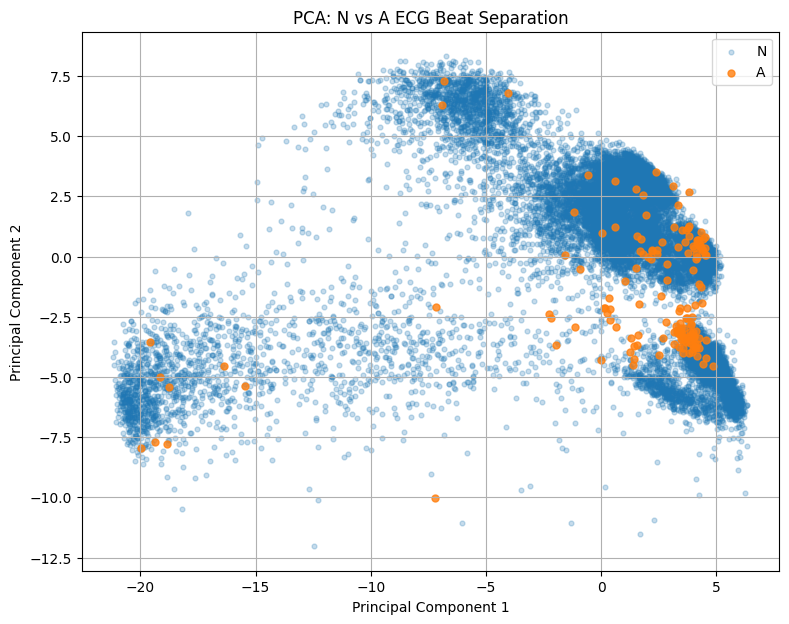

In [138]:
# ============================================================
# PCA ANALYSIS: N vs A SEPARABILITY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. Use TRAINING DATA ONLY
# ------------------------------------------------------------

X_pca = X_train_cnn[:, :, 0]
y_pca = y_train_encoded

# Keep only N (0) and A (1)
mask_NA = np.isin(y_pca, [0, 1])

X_NA = X_pca[mask_NA]
y_NA = y_pca[mask_NA]

print("N/A PCA input shape:", X_NA.shape)

print("\nClass distribution:")
print("N:", np.sum(y_NA == 0))
print("A:", np.sum(y_NA == 1))

# ------------------------------------------------------------
# 2. PCA
# ------------------------------------------------------------

pca = PCA(n_components=2)

X_pca_2d = pca.fit_transform(X_NA)

print("\nPCA explained variance:")
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])

print(
    "Total explained variance:",
    np.sum(pca.explained_variance_ratio_)
)

# ------------------------------------------------------------
# 3. Plot N vs A
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

N_mask = y_NA == 0
A_mask = y_NA == 1

plt.scatter(
    X_pca_2d[N_mask, 0],
    X_pca_2d[N_mask, 1],
    alpha=0.25,
    s=12,
    label="N"
)

plt.scatter(
    X_pca_2d[A_mask, 0],
    X_pca_2d[A_mask, 1],
    alpha=0.8,
    s=25,
    label="A"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: N vs A ECG Beat Separation")
plt.legend()
plt.grid(True)

plt.show()

**LDA**

In [146]:
# Show variables in the notebook that may contain validation data

for name, value in globals().items():
    if name.startswith("_"):
        continue

    try:
        shape = value.shape
        if len(shape) >= 1:
            print(name, "->", shape)
    except:
        pass

ecg -> (650000,)
time -> (650000,)
mask -> (2274,)
ann_samples -> (10,)
ann_symbols -> (10,)
ann_times -> (10,)
b -> (2153, 216)
a -> (9,)
ecg_filtered -> (650000,)
r_peaks -> (2273,)
peaks_10s -> (13,)
r_peak_times -> (2273,)
annotation_samples_10s -> (14,)
annotation_symbols_10s -> (14,)
beat -> (216,)
beat_time -> (216,)
beats -> (2153, 216)
beat_peak_positions -> (2272,)
filtered_samples -> (2272,)
filtered_symbols -> (2272,)
matched_labels -> (2271,)
matched_peaks -> (2271,)
distances -> (2272,)
nearby -> (5,)
selected_labels -> (2273,)
selected_samples -> (2273,)
expert_beats -> (2272, 216)
expert_labels -> (2272,)
beats_106 -> (2027, 216)
labels_106 -> (2027,)
labels -> (3066,)
X_train -> (22760, 216)
y_train -> (22760,)
X_val -> (5000, 216)
y_val -> (5000,)
X_test -> (4751, 216)
y_test -> (4751,)
y_train_encoded -> (22760,)
y_val_encoded -> (5000,)
y_test_encoded -> (4751,)
X_train_norm -> (22760, 216)
X_val_norm -> (5000, 216)
X_test_norm -> (4751, 216)
classes -> (3,)
class_w

In [147]:
# Show variables in the notebook that may contain validation data

for name, value in globals().items():
    if name.startswith("_"):
        continue

    try:
        shape = value.shape
        if len(shape) >= 1:
            print(name, "->", shape)
    except:
        pass

ecg -> (650000,)
time -> (650000,)
mask -> (2274,)
ann_samples -> (10,)
ann_symbols -> (10,)
ann_times -> (10,)
b -> (2153, 216)
a -> (9,)
ecg_filtered -> (650000,)
r_peaks -> (2273,)
peaks_10s -> (13,)
r_peak_times -> (2273,)
annotation_samples_10s -> (14,)
annotation_symbols_10s -> (14,)
beat -> (216,)
beat_time -> (216,)
beats -> (2153, 216)
beat_peak_positions -> (2272,)
filtered_samples -> (2272,)
filtered_symbols -> (2272,)
matched_labels -> (2271,)
matched_peaks -> (2271,)
distances -> (2272,)
nearby -> (5,)
selected_labels -> (2273,)
selected_samples -> (2273,)
expert_beats -> (2272, 216)
expert_labels -> (2272,)
beats_106 -> (2027, 216)
labels_106 -> (2027,)
labels -> (3066,)
X_train -> (22760, 216)
y_train -> (22760,)
X_val -> (5000, 216)
y_val -> (5000,)
X_test -> (4751, 216)
y_test -> (4751,)
y_train_encoded -> (22760,)
y_val_encoded -> (5000,)
y_test_encoded -> (4751,)
X_train_norm -> (22760, 216)
X_val_norm -> (5000, 216)
X_test_norm -> (4751, 216)
classes -> (3,)
class_w

Validation LDA input shape: (4761, 216)
Validation N samples: 4700
Validation A samples: 61

Validation LDA transformation completed.
Validation LDA output shape: (4761,)

Validation LDA score statistics
--------------------------------
N:
Mean: -0.907580420045048
Std : 1.5494898451912518
Min : -6.633927613122523
Max : 4.090683598688713

A:
Mean: 1.6504149937892938
Std : 3.4940323029603637
Min : -7.61418920620298
Max : 9.686069815582869

Validation standardized mean separation:
0.9464590573445418

Validation LDA ROC-AUC:
0.7680362748517615


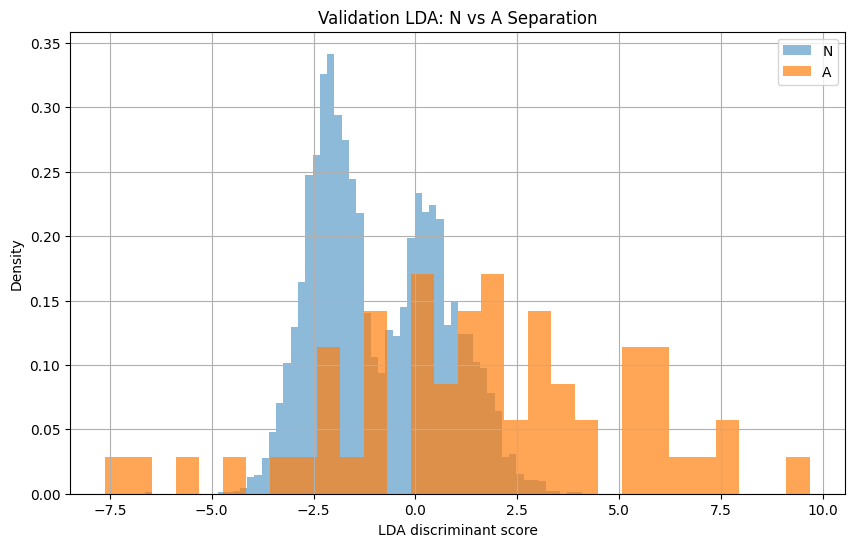

In [148]:
# ============================================================
# VALIDATION LDA: N vs A SEPARABILITY
# ============================================================

# Validation N/A data
X_val_lda = X_val_NA
y_val_lda = y_val_NA

print("Validation LDA input shape:", X_val_lda.shape)
print("Validation N samples:", np.sum(y_val_lda == 0))
print("Validation A samples:", np.sum(y_val_lda == 1))

# ------------------------------------------------------------
# Transform validation data using TRAINED LDA
# ------------------------------------------------------------

X_val_lda_1d = lda.transform(X_val_lda).ravel()

print("\nValidation LDA transformation completed.")
print("Validation LDA output shape:", X_val_lda_1d.shape)

# ------------------------------------------------------------
# Separate N and A scores
# ------------------------------------------------------------

val_N_scores = X_val_lda_1d[y_val_lda == 0]
val_A_scores = X_val_lda_1d[y_val_lda == 1]

print("\nValidation LDA score statistics")
print("--------------------------------")

print("N:")
print("Mean:", np.mean(val_N_scores))
print("Std :", np.std(val_N_scores))
print("Min :", np.min(val_N_scores))
print("Max :", np.max(val_N_scores))

print("\nA:")
print("Mean:", np.mean(val_A_scores))
print("Std :", np.std(val_A_scores))
print("Min :", np.min(val_A_scores))
print("Max :", np.max(val_A_scores))

# ------------------------------------------------------------
# Standardized mean separation
# ------------------------------------------------------------

mean_N_val = np.mean(val_N_scores)
mean_A_val = np.mean(val_A_scores)

pooled_std_val = np.sqrt(
    (np.var(val_N_scores) + np.var(val_A_scores)) / 2
)

separation_val = abs(
    mean_A_val - mean_N_val
) / pooled_std_val

print("\nValidation standardized mean separation:")
print(separation_val)

# ------------------------------------------------------------
# ROC-AUC
# ------------------------------------------------------------

val_auc = roc_auc_score(
    y_val_lda,
    X_val_lda_1d
)

# LDA direction can be reversed
val_auc = max(val_auc, 1 - val_auc)

print("\nValidation LDA ROC-AUC:")
print(val_auc)

# ------------------------------------------------------------
# Plot validation LDA distributions
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    val_N_scores,
    bins=60,
    alpha=0.5,
    label="N",
    density=True
)

plt.hist(
    val_A_scores,
    bins=30,
    alpha=0.7,
    label="A",
    density=True
)

plt.xlabel("LDA discriminant score")
plt.ylabel("Density")
plt.title("Validation LDA: N vs A Separation")
plt.legend()
plt.grid(True)

plt.show()

In [149]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# VALIDATION LDA: FIND OPTIMAL THRESHOLD
# ============================================================

# LDA was already trained on TRAINING N/A data
# lda.fit(X_NA, y_NA)

# Transform validation data using TRAINED LDA
X_val_lda = lda.transform(X_val_NA).ravel()

# ------------------------------------------------------------
# ROC curve
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_val_NA,
    X_val_lda
)

auc = roc_auc_score(
    y_val_NA,
    X_val_lda
)

# LDA direction correction
if auc < 0.5:
    X_val_lda = -X_val_lda

    fpr, tpr, thresholds = roc_curve(
        y_val_NA,
        X_val_lda
    )

    auc = roc_auc_score(
        y_val_NA,
        X_val_lda
    )

print("Validation ROC-AUC:", auc)

# ------------------------------------------------------------
# Youden's J statistic
# J = Sensitivity + Specificity - 1
# ------------------------------------------------------------

J = tpr - fpr

best_idx = np.argmax(J)
best_threshold = thresholds[best_idx]

print("\nOptimal threshold:")
print(best_threshold)

print("\nSensitivity:", tpr[best_idx])
print("Specificity:", 1 - fpr[best_idx])
print("Youden J:", J[best_idx])

# ------------------------------------------------------------
# Classify validation samples
# ------------------------------------------------------------

y_val_lda_pred = (
    X_val_lda >= best_threshold
).astype(int)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm_lda = confusion_matrix(
    y_val_NA,
    y_val_lda_pred
)

print("\nValidation LDA Confusion Matrix:")
print(cm_lda)

print("\nValidation Classification Report:")
print(
    classification_report(
        y_val_NA,
        y_val_lda_pred,
        target_names=["N", "A"],
        zero_division=0
    )
)

Validation ROC-AUC: 0.7680362748517615

Optimal threshold:
1.2432004689807172

Sensitivity: 0.5901639344262295
Specificity: 0.8980851063829787
Youden J: 0.4882490408092082

Validation LDA Confusion Matrix:
[[4221  479]
 [  25   36]]

Validation Classification Report:
              precision    recall  f1-score   support

           N       0.99      0.90      0.94      4700
           A       0.07      0.59      0.12        61

    accuracy                           0.89      4761
   macro avg       0.53      0.74      0.53      4761
weighted avg       0.98      0.89      0.93      4761



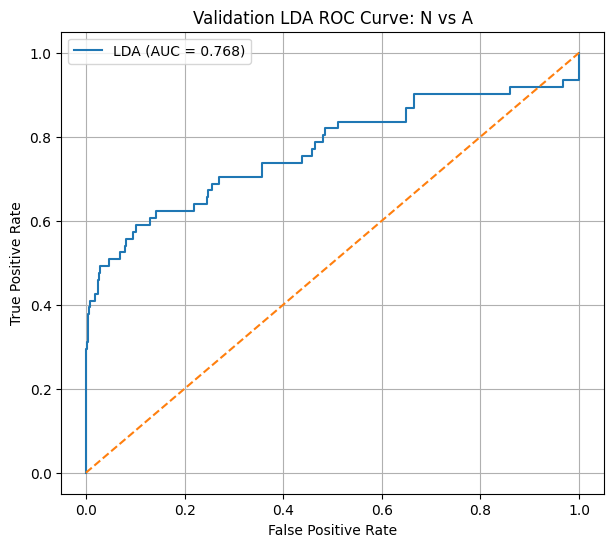

In [150]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"LDA (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation LDA ROC Curve: N vs A")

plt.legend()
plt.grid(True)

plt.show()